In [1398]:
import spike.spike_analysis.spike_collection as spike_collection
import spike.spike_analysis.spike_recording as sr
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.normalization as norm
import spike.spike_analysis.single_cell as single_cell
from spike.spike_analysis.spike_collection import SpikeCollection
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import behavior.boris_extraction as boris
import matplotlib.pyplot as plt
import pickle
import re
import seaborn as sns

# Set global seaborn style
sns.set_context("notebook", font_scale=1.9)

# Define color palette for Day 0 (Teal) and Day 7 (Magenta)
COLOR_DAY0 = '#53A1A9'  # Teal
COLOR_DAY7 = '#A95376'  # Magenta

In [1399]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [1400]:
json_path = r"C:\Users\thoma\Code\ResearchCode\rehouse\diff_fam_social_memory_ephys\thomas-social-memory\data\spike_collection.json"
sc = SpikeCollection.load_collection(json_path)

In [1401]:
# ============================================================================
# FILTER RECORDINGS: Keep only subjects with BOTH d0 AND d7
# ============================================================================
print("="*80)
print("FILTERING RECORDINGS TO ENSURE PAIRED d0/d7 DATA")
print("="*80)

# Extract subject IDs and days from all recordings
subjects_by_day = {'d0': set(), 'd7': set()}

for rec in sc.recordings:
    rec_name = rec.name
    # Extract subject number (e.g., "22" from "22_rehouse_d0_merged.rec")
    subject_match = re.match(r'(\d+)_', rec_name)
    if subject_match:
        subject_id = subject_match.group(1)
        
        # Determine day
        if '_d0_' in rec_name or rec_name.endswith('_d0.rec'):
            subjects_by_day['d0'].add(subject_id)
        elif '_d7_' in rec_name or rec_name.endswith('_d7.rec'):
            subjects_by_day['d7'].add(subject_id)

print(f"\nSubjects with d0 recordings: {sorted(subjects_by_day['d0'])}")
print(f"Subjects with d7 recordings: {sorted(subjects_by_day['d7'])}")

# Find subjects that have BOTH d0 and d7
subjects_with_both = subjects_by_day['d0'] & subjects_by_day['d7']
subjects_missing_d0 = subjects_by_day['d7'] - subjects_by_day['d0']
subjects_missing_d7 = subjects_by_day['d0'] - subjects_by_day['d7']

print(f"\n✓ Subjects with BOTH d0 and d7: {sorted(subjects_with_both)}")
if subjects_missing_d0:
    print(f"⚠️ Subjects missing d0 (will be EXCLUDED): {sorted(subjects_missing_d0)}")
if subjects_missing_d7:
    print(f"⚠️ Subjects missing d7 (will be EXCLUDED): {sorted(subjects_missing_d7)}")

# Filter recordings to keep only those from subjects with both days
original_count = len(sc.recordings)
filtered_recordings = []
excluded_recordings = []

for rec in sc.recordings:
    rec_name = rec.name
    subject_match = re.match(r'(\d+)_', rec_name)
    if subject_match:
        subject_id = subject_match.group(1)
        if subject_id in subjects_with_both:
            filtered_recordings.append(rec)
        else:
            excluded_recordings.append(rec_name)
    else:
        # Keep recordings without clear subject ID pattern (shouldn't happen)
        filtered_recordings.append(rec)

# Update the SpikeCollection with filtered recordings
sc.recordings = filtered_recordings

print(f"\n{'='*80}")
print(f"FILTERING RESULTS")
print(f"{'='*80}")
print(f"Original recording count:  {original_count}")
print(f"Filtered recording count:  {len(sc.recordings)}")
print(f"Recordings excluded:       {len(excluded_recordings)}")

if excluded_recordings:
    print(f"\nExcluded recordings:")
    for rec_name in excluded_recordings:
        print(f"  - {rec_name}")

print(f"\n✓ Analysis will proceed with {len(subjects_with_both)} subjects (paired d0/d7)")
print("="*80)

FILTERING RECORDINGS TO ENSURE PAIRED d0/d7 DATA

Subjects with d0 recordings: ['22', '32', '41', '44']
Subjects with d7 recordings: ['22', '31', '32', '41', '44']

✓ Subjects with BOTH d0 and d7: ['22', '32', '41', '44']
⚠️ Subjects missing d0 (will be EXCLUDED): ['31']

FILTERING RESULTS
Original recording count:  9
Filtered recording count:  8
Recordings excluded:       1

Excluded recordings:
  - 31_rehouse_d7_merged.rec

✓ Analysis will proceed with 4 subjects (paired d0/d7)


In [1402]:
epoch_bins = {}

condition_order = {
    # --- Subject 22 ---
    ("22", "d0"): "OM",
    ("22", "d7"): "MO",

    # --- Subject 23 ---
    ("23", "d0"): "MO",
    ("23", "d7"): "OM",

    # --- Subject 31 ---
    ("31", "d0"): "OM",
    ("31", "d7"): "MO",

    # --- Subject 32 ---
    ("32", "d0"): "MO",
    ("32", "d7"): "OM",

    # --- Subject 41 ---
    ("41", "d0"): "OM",
    ("41", "d7"): "MO",

    # --- Subject 44 ---
    ("44", "d0"): "MO",
    ("44", "d7"): "OM",
}


In [1403]:
# help function to get epoch labels based on condition order
def get_epoch_labels(subject, day):
    order = condition_order.get((str(subject), str(day)))
    if order == "MO":
        return {"social": "first", "object": "second"}
    elif order == "OM":
        return {"social": "second", "object": "first"}
    else:
        raise ValueError(f"Unknown order for subject {subject}")

# returns a dict mapping "social" and "object" to "first" and "second" based on condition order
def epoch_rows_builder(rec):
    epoch_rows = []
    if "d0" in rec.name:
        day = "d0"
    elif "d7" in rec.name:
        day = "d7"
    else:
        day = "unknown"
        print("Day not available for recording:", rec.name)
    subj = getattr(rec, "subject", "unknown")
    try:
        epoch_map = get_epoch_labels(subj, day)
        print(f"{rec.name}: {epoch_map}")
        return epoch_map
    except ValueError:
        # skip subjects without a defined condition order
        print(f"Skipping recording {rec.name} due to unknown condition order.")
        pass

# example usage
for rec in sc.recordings:
    epoch_rows_builder(rec)

22_rehouse_d0_merged.rec: {'social': 'second', 'object': 'first'}
22_rehouse_d7_merged.rec: {'social': 'first', 'object': 'second'}
32_rehouse_d0_merged.rec: {'social': 'first', 'object': 'second'}
32_rehouse_d7_merged.rec: {'social': 'second', 'object': 'first'}
41_rehouse_d0_merged.rec: {'social': 'second', 'object': 'first'}
41_rehouse_d7_merged.rec: {'social': 'first', 'object': 'second'}
44_rehouse_d0_merged.rec: {'social': 'first', 'object': 'second'}
44_rehouse_d7_merged.rec: {'social': 'second', 'object': 'first'}


In [1404]:
# create epoch time bins in seconds based on recording length and epoch map
def create_bins(rec_length, epoch_map):
    '''
    rec_length: float, length of recording in seconds
    epoch_map: dict, mapping of "social" and "object" to "first" and "second"
    '''

    if rec_length is not None and epoch_map is not None:
        print("Recording length:", rec_length)
        bins = {
            "baseline": (0, rec_length/3),    # 0–10 min
            epoch_map["social"]: (rec_length/3, 2*rec_length/3), # 10–20 min
            epoch_map["object"]: (2*rec_length/3, rec_length)  # 20–30 min
        }
        return bins
    
    else:
        raise ValueError("Recording length is None or epoch_map is None")

# Poisson Event Test

In [ ]:
import numpy as np
from scipy.stats import norm

def poisson_event_test(recording, event_name, equalize=None, sides='two-sided'):
    sr = recording.sampling_rate
    
    # Get good units - store the actual spike arrays, not their lengths
    # First try to get good_units attribute, otherwise use labels_dict
    good_units = getattr(recording, "good_units", None)
    if good_units is None:
        # Use labels_dict if available
        if hasattr(recording, 'labels_dict'):
            good_units = [unit_id for unit_id, label in recording.labels_dict.items() if label == "good"]
        else:
            # Fall back to all units with spikes
            good_units = [unit for unit, ts in recording.unit_timestamps.items() if len(ts) > 0]
    
    # Filter unit_timestamps to only good units with spike data
    rec_gunits = {unit: recording.unit_timestamps[unit] for unit in good_units 
                  if unit in recording.unit_timestamps and len(recording.unit_timestamps[unit]) > 0}
    
    # Calculate recording duration: find max spike timestamp across good units
    max_timestamp = 0
    counts_all = {}
    
    for unit, ts in rec_gunits.items():
        counts_all[unit] = len(ts)
        if len(ts) > 0:
            max_timestamp = max(max_timestamp, ts[-1])  # ts is already sorted
    
    # Total recording time in seconds
    T_all = max_timestamp / sr if max_timestamp > 0 else 1.0  # avoid division by zero

    # Global rate per unit
    lam_global = {u: counts_all[u] / T_all for u in counts_all}
    
    # Estimate per-unit Fano factor to account for overdispersion
    # CRITICAL: Use bin size matching the event duration (equalize parameter)
    # If equalize is provided, use that; otherwise calculate from event durations
    if equalize is not None:
        bin_size_s = equalize  # Match the event window duration
    else:
        # Calculate average event duration from the actual event windows
        print("Not using equalize")
        events = recording.event_dict[event_name]
        event_durations_s = [(stop_ms - start_ms) / 1000.0 for start_ms, stop_ms in events]
        if len(event_durations_s) > 0:
            bin_size_s = np.mean(event_durations_s)  # Use mean event duration
        else:
            bin_size_s = 5.0  # Fallback to 5 seconds if no events
    
    fano_factors = {}
    n_bins = int(np.floor(T_all / bin_size_s))  # Use floor to ensure full bins
    
    # Need at least 3 bins for reasonable variance estimate
    if n_bins < 3:
        # If recording is too short, fall back to simple Poisson (F=1)
        for unit in rec_gunits.keys():
            fano_factors[unit] = 1.0
    else:
        for unit, ts in rec_gunits.items():
            # Convert timestamps to seconds
            spike_times_s = ts / sr
            # Bin spike counts in non-overlapping bins matching event duration
            counts_per_bin = np.histogram(spike_times_s, bins=n_bins, range=(0, n_bins * bin_size_s))[0]
            
            # Fano factor = variance / mean
            mean_count = np.mean(counts_per_bin)
            if mean_count > 0.1:  # Need reasonable spike count for reliable estimate
                var_count = np.var(counts_per_bin, ddof=1)  # Use sample variance (ddof=1)
                F = var_count / mean_count
                # Ensure F >= 1.0 (can't be less dispersed than Poisson)
                fano_factors[unit] = max(1.0, F)
            else:
                # For very sparse firing, assume Poisson
                fano_factors[unit] = 1.0

    events = recording.event_dict[event_name]  # list of [start_ms, stop_ms]
    results = []
    for unit, ts in rec_gunits.items():
        # event counts & durations (binless)
        # convert unit spikes to ms to use searchsorted efficiently
        spike_ms = ts * (1000.0 / sr)
        N = 0
        T = 0.0
        for start_ms, stop_ms in events:
            if equalize is not None:
                stop_ms = min(stop_ms, start_ms + 1000*equalize)
            # count spikes in (start_ms, stop_ms]
            i0 = np.searchsorted(spike_ms, start_ms, side='left')
            i1 = np.searchsorted(spike_ms, stop_ms, side='right')
            N += (i1 - i0)
            T += (stop_ms - start_ms) / 1000.0

        if T <= 0 or lam_global[unit] <= 0:
            continue

        FR_event = N / T if T > 0 else 0
        mu = lam_global[unit] * T
        # Use empirical Fano factor to account for overdispersion
        F = fano_factors[unit]
        z = (N - mu) / np.sqrt(F * mu)
        if sides == 'two-sided':
            p = 2 * norm.sf(abs(z))
        elif sides == 'greater':
            p = norm.sf(z)
        else:
            p = norm.cdf(z)

        results.append({
            "Recording": recording.name,
            "Event": event_name,
            "Unit": unit,
            "T_event_s": T,
            "N_event": N,
            "FR_event_Hz": FR_event,
            "lambda_global": lam_global[unit],
            "Fano_factor": fano_factors[unit],
            "z": z,
            "p": p,
            "sig": ("increase" if (sides!='less' and z > 2.58)
                    else "decrease" if (sides!='greater' and z < -1.96)
                    else "not sig")
        })
    return results


In [1406]:
# Quick test to verify the function works on a single recording
test_rec = sc.recordings[0]
print(f"Testing on recording: {test_rec.name}")
print(f"Available events: {list(test_rec.event_dict.keys())}")

# Get first available event
if test_rec.event_dict:
    test_event = list(test_rec.event_dict.keys())[0]
    print(f"\nTesting with event: {test_event}")
    print(f"Number of event windows: {len(test_rec.event_dict[test_event])}")
    
    # Run test
    test_results = poisson_event_test(test_rec, test_event, equalize=10)
    print(f"\nResults: {len(test_results)} units analyzed")
    if test_results:
        print("\nFirst few results:")
        for r in test_results[:3]:
            print(f"  Unit {r['Unit']}: z={r['z']:.2f}, p={r['p']:.4f}, sig={r['sig']}")
else:
    print("No events available in this recording")

Testing on recording: 22_rehouse_d0_merged.rec
Available events: ['anogenital sniffing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object']

Testing with event: anogenital sniffing
Number of event windows: 19

Results: 14 units analyzed

First few results:
  Unit 13: z=-1.70, p=0.0898, sig=not sig
  Unit 14: z=-0.08, p=0.9354, sig=not sig
  Unit 25: z=-1.05, p=0.2943, sig=not sig


# Test False Positive Rate with Random Non-Event Segments

In [1407]:
# RIGOROUS False Positive Rate Test with Multiple Recordings and Iterations
print("="*80)
print("RIGOROUS FALSE POSITIVE RATE TEST")
print("="*80)
print("Testing with random non-event segments across multiple recordings")
print("using event-type-specific durations to ensure statistical validity.\n")

n_iterations = 30  # Increased from 5 for better statistical power
all_test_results = []

# Collect event durations across all recordings for each event type, separated by day
event_durations_by_type = {}  # All events combined (for backward compatibility)
event_durations_by_type_and_day = {}  # Separated by d0 and d7

for rec in sc.recordings:
    # Determine which day this recording is from
    day = extract_day_from_recording(rec.name)
    
    for event_name, event_windows in rec.event_dict.items():
        # Collect all durations (combined)
        if event_name not in event_durations_by_type:
            event_durations_by_type[event_name] = []
        
        # Collect durations by day
        key = (event_name, day)
        if key not in event_durations_by_type_and_day:
            event_durations_by_type_and_day[key] = []
        
        for start_ms, stop_ms in event_windows:
            duration_ms = stop_ms - start_ms
            event_durations_by_type[event_name].append(duration_ms)
            event_durations_by_type_and_day[key].append(duration_ms)

# Print event duration statistics by day
print("Event Duration Statistics (from real behavioral events):")
print("=" * 100)
print(f"{'Event':<30s} {'Day':>5s} {'Mean (s)':>10s} {'Median (s)':>12s} {'Std (s)':>10s} {'N':>6s}")
print("-" * 100)

# Get unique event names and sort them
all_events = sorted(set(event_name for event_name, day in event_durations_by_type_and_day.keys()))

for event_name in all_events:
    # Print d0 stats if available
    key_d0 = (event_name, 'd0')
    if key_d0 in event_durations_by_type_and_day:
        durations = event_durations_by_type_and_day[key_d0]
        mean_dur = np.mean(durations) / 1000
        std_dur = np.std(durations) / 1000
        median_dur = np.median(durations) / 1000
        print(f"  {event_name:<28s} {'d0':>5s} {mean_dur:>10.2f} {median_dur:>12.2f} {std_dur:>10.2f} {len(durations):>6d}")
    
    # Print d7 stats if available
    key_d7 = (event_name, 'd7')
    if key_d7 in event_durations_by_type_and_day:
        durations = event_durations_by_type_and_day[key_d7]
        mean_dur = np.mean(durations) / 1000
        std_dur = np.std(durations) / 1000
        median_dur = np.median(durations) / 1000
        print(f"  {event_name:<28s} {'d7':>5s} {mean_dur:>10.2f} {median_dur:>12.2f} {std_dur:>10.2f} {len(durations):>6d}")
    
    # Add spacing between different events for readability
    if key_d0 in event_durations_by_type_and_day and key_d7 in event_durations_by_type_and_day:
        print()

print("=" * 100)
print()

# Test on multiple recordings for robustness
test_recordings = sc.recordings[:min(5, len(sc.recordings))]  # Increased from 3

for test_rec in test_recordings:
    sr = test_rec.sampling_rate
    
    # Get recording duration
    max_timestamp = max(max(ts) if len(ts) > 0 else 0 
                        for ts in test_rec.unit_timestamps.values())
    rec_duration_ms = (max_timestamp / sr) * 1000
    
    # Get a real event to use as template for timing
    if not test_rec.event_dict:
        continue
    real_event = list(test_rec.event_dict.keys())[0]
    real_windows = test_rec.event_dict[real_event]
    
    # Get event durations for this event type (for sampling)
    if real_event not in event_durations_by_type or len(event_durations_by_type[real_event]) == 0:
        print(f"  Skipping {test_rec.name}: no duration data for {real_event}")
        continue
    event_durations_pool = event_durations_by_type[real_event]
    
    print(f"\nTesting recording: {test_rec.name}")
    print(f"  Duration: {rec_duration_ms/1000:.1f}s")
    print(f"  Event type: {real_event}")
    print(f"  Number of real event windows: {len(real_windows)}")
    print(f"  Using {len(event_durations_pool)} duration samples from real {real_event} events")
    
    # Run multiple iterations with different random seeds
    for iteration in range(n_iterations):
        # Use truly independent randomness (system entropy)
        np.random.seed(None)  # Critical fix: use system time/entropy for independence
        fake_events = []
        
        attempts = 0
        max_attempts = len(real_windows) * 20  # Increased because variable durations make placement harder
        
        while len(fake_events) < len(real_windows) and attempts < max_attempts:
            # Sample a duration from the real event type's duration distribution
            sampled_duration_ms = np.random.choice(event_durations_pool)
            
            # Generate non-overlapping fake events with sampled duration
            max_start = rec_duration_ms - sampled_duration_ms - 1000  # leave 1s buffer
            if max_start <= 0:
                attempts += 1
                continue
            
            random_start = np.random.uniform(0, max_start)
            random_end = random_start + sampled_duration_ms
            
            # Check for overlaps with existing fake events
            overlaps = False
            for existing_start, existing_end in fake_events:
                if not (random_end < existing_start or random_start > existing_end):
                    overlaps = True
                    break
            
            if not overlaps:
                fake_events.append([random_start, random_end])
            
            attempts += 1
        
        # Warn if we couldn't generate enough non-overlapping events
        if len(fake_events) < len(real_windows) * 0.8:  # At least 80% success
            print(f"  Iteration {iteration}: Warning - only generated {len(fake_events)}/{len(real_windows)} non-overlapping events")
        
        # Add fake events to recording temporarily
        test_rec.event_dict['fake_event'] = fake_events
        
        # Run test without equalizing (use actual sampled durations)
        results = poisson_event_test(test_rec, 'fake_event', equalize=None)
        
        if results:
            all_test_results.extend(results)
        
        # Clean up
        del test_rec.event_dict['fake_event']

# Aggregate results across all recordings and iterations
if all_test_results:
    n_sig = sum(1 for r in all_test_results if r['sig'] != 'not sig')
    n_increase = sum(1 for r in all_test_results if r['sig'] == 'increase')
    n_decrease = sum(1 for r in all_test_results if r['sig'] == 'decrease')
    total_tests = len(all_test_results)
    fpr = n_sig / total_tests
    
    # Extract Fano factors and z-scores for diagnostics
    fano_factors = [r['Fano_factor'] for r in all_test_results]
    z_scores = [r['z'] for r in all_test_results]
    
    print(f"\n{'='*80}")
    print(f"AGGREGATED RESULTS ACROSS {len(test_recordings)} RECORDINGS × {n_iterations} ITERATIONS")
    print(f"{'='*80}")
    print(f"Total unit×iteration tests: {total_tests}")
    
    # Check if sample size is sufficient
    if total_tests < 500:
        print(f"\n⚠️ WARNING: Only {total_tests} tests performed.")
        print(f"   For robust FPR estimation, consider increasing n_iterations or test_recordings")
        print(f"   Recommended: At least 1000 tests for reliable FPR estimates")
    elif total_tests < 1000:
        print(f"\n⚠️ CAUTION: {total_tests} tests performed (recommended: ≥1000 for high confidence)")
    
    print(f"\nSignificant tests: {n_sig} ({fpr*100:.2f}%)")
    print(f"  - Increases (z > 2.58): {n_increase} ({100*n_increase/total_tests:.2f}%)")
    print(f"  - Decreases (z < -1.96): {n_decrease} ({100*n_decrease/total_tests:.2f}%)")
    print(f"  - Not significant: {total_tests - n_sig} ({100*(total_tests-n_sig)/total_tests:.2f}%)")
    
    print(f"\nFano Factor Statistics:")
    print(f"  Mean: {np.mean(fano_factors):.2f}")
    print(f"  Median: {np.median(fano_factors):.2f}")
    print(f"  Range: [{np.min(fano_factors):.2f}, {np.max(fano_factors):.2f}]")
    
    print(f"\nZ-Score Statistics (should be ~N(0,1)):")
    print(f"  Mean: {np.mean(z_scores):.3f} (expected: 0.0)")
    print(f"  Std: {np.std(z_scores):.3f} (expected: 1.0)")
    print(f"  Range: [{np.min(z_scores):.2f}, {np.max(z_scores):.2f}]")
    
    print(f"\n{'='*80}")
    print(f"THEORETICAL EXPECTATIONS")
    print(f"{'='*80}")
    print(f"Expected FPR with z > 2.58 (one-tailed): ~0.49%")
    print(f"Expected FPR with z < -1.96 (one-tailed): ~2.50%")
    print(f"Expected TOTAL FPR (asymmetric): ~2.99%")
    
    print(f"\n{'='*80}")
    print(f"OBSERVED vs EXPECTED")
    print(f"{'='*80}")
    print(f"Observed Total FPR: {fpr*100:.2f}%")
    print(f"Expected Total FPR: ~3.0%")
    
    # Statistical test: binomial test (use scipy.stats.binomtest when available; fallback otherwise)
    try:
        # SciPy >= 1.7
        from scipy.stats import binomtest
        p_value = binomtest(n_sig, total_tests, 0.03, alternative='greater').pvalue
    except Exception:
        try:
            # Older SciPy: deprecated function
            from scipy.stats import binom_test
            p_value = binom_test(n_sig, total_tests, 0.03, alternative='greater')
        except Exception:
            # Last-resort exact calculation using survival function
            from scipy.stats import binom
            p_value = binom.sf(n_sig - 1, total_tests, 0.03)
    print(f"\nBinomial test (H0: FPR = 3%):")
    print(f"  p-value = {p_value:.4f}")
    
    if fpr > 0.05:
        print("\n⚠️ WARNING: False positive rate is higher than 5%!")
        print("   Consider further increasing thresholds or adding FDR correction.")
    elif fpr > 0.04:
        print("\n⚠️ CAUTION: FPR is slightly elevated but acceptable.")
    elif p_value > 0.05:
        print("\n✓ PASS: FPR is statistically consistent with expected ~3%.")
    else:
        print("\n✓✓ EXCELLENT: FPR is well-controlled and conservative.")
    
    # Distribution visualization
    print(f"\nZ-Score Distribution (first 20 bins):")
    hist, bins = np.histogram(z_scores, bins=20, range=(-4, 4))
    max_bar_width = 50
    max_count = max(hist)
    for i in range(len(hist)):
        bar_width = int(hist[i] / max_count * max_bar_width) if max_count > 0 else 0
        print(f"  {bins[i]:5.2f} - {bins[i+1]:5.2f}: {'█' * bar_width} {hist[i]}")
else:
    print("No results generated")

RIGOROUS FALSE POSITIVE RATE TEST
Testing with random non-event segments across multiple recordings
using event-type-specific durations to ensure statistical validity.

Event Duration Statistics (from real behavioral events):
Event                            Day   Mean (s)   Median (s)    Std (s)      N
----------------------------------------------------------------------------------------------------
  anogenital sniffing             d0       2.59         1.70       3.67     68
  anogenital sniffing             d7       2.58         1.63       3.41     60

  chasing                         d7       0.55         0.52       0.13      4
  facial sniffing                 d0       1.08         0.87       0.90     52
  facial sniffing                 d7       1.37         1.04       0.94     65

  fighting                        d0       5.82         3.52       5.40      4
  fighting                        d7       0.81         0.81       0.00      1

  mice back in                    d0  

In [1408]:
print(f"Mean Fano: {np.mean(fano_factors):.2f}")
print(f"Median Fano: {np.median(fano_factors):.2f}")
print(f"Range: [{np.min(fano_factors):.2f}, {np.max(fano_factors):.2f}]")
print(f"Fraction > 1.5: {np.mean(np.array(fano_factors) > 1.5)*100:.1f}%")


Mean Fano: 6.92
Median Fano: 5.45
Range: [1.00, 36.89]
Fraction > 1.5: 89.5%


### ✅ Fano Factor Correction Applied & Test Methodology Validated

**Problem identified:** The original test showed 57% false positive rate (expected ~3%), indicating severe variance underestimation.

**Root cause:** Real neural spike trains are **overdispersed** — they have more variability than a pure Poisson process predicts. The Poisson assumption `Var = λT` is too optimistic.

**Solution implemented:** 
- Calculate each unit's empirical **Fano factor** (F = Variance/Mean) using 1-second bins across the entire recording
- F ≈ 1.0 for perfect Poisson, but real neurons typically have F ≈ 1.5-4
- Use this in the z-score: `z = (N - μ) / √(F·μ)` instead of `z = (N - μ) / √μ`

This inflates the standard deviation appropriately, making the test more conservative and reducing false positives.

**Recent Test Improvements (Nov 2025):**
1. **Independent Randomness:** Changed from sequential seeds (42, 43, 44...) to `np.random.seed(None)` for true independence
2. **Overlap Prevention:** Fake events are now checked to ensure they don't overlap with each other
3. **Increased Power:** 10 iterations (up from 5) across 5 recordings (up from 3) for more robust estimates
4. **Sample Size Warnings:** Alerts if total tests < 1000, which is recommended for reliable FPR estimation

**Why these matter:**
- Sequential seeds can introduce subtle correlations between iterations
- Overlapping fake events inflate spike counts and violate independence assumptions
- More iterations provide better statistical power to detect if FPR deviates from expected 3%

**Next step:** Re-run the false positive test above to verify FPR is now < 5% with improved methodology.

### How It Works

**Statistical Model:**
1. Calculate each neuron's global firing rate: λ = total spikes / total time
2. For each event, count spikes across all trials: N
3. Calculate expected spike count under null hypothesis: μ = λ × event_time
4. Z-score: z = (N - μ) / √(F·μ), where F is the Fano factor (default=1)
5. P-value from standard normal distribution

**Key Advantages:**
- No arbitrary timebin choices (binless)
- Accounts for baseline firing rate differences
- Statistically principled for count data
- Can be extended with Fano factor for over-dispersion

**Parameters:**
- `equalize`: Duration (seconds) to standardize event windows (None = use full duration)
- `sides`: 'two-sided' (increases or decreases), 'greater' (increases only), 'less' (decreases only)
- `alpha`: Significance threshold (default 0.05)

In [1409]:
def run_all_recordings_all_events_poisson(sp, equalize=10, sides='two-sided', alpha=0.05, verbose=False, use_event_durations=False):
    """
    Run Poisson-based event test for all recordings and all event types.
    
    Parameters:
    - sp: SpikeCollection object containing a list of recordings.
    - equalize: Duration in seconds to equalize event windows (default 10s, None for full duration).
                Ignored if use_event_durations=True.
    - sides: 'two-sided', 'greater', or 'less' for hypothesis testing.
    - alpha: Significance level for p-value threshold (default 0.05).
    - verbose: If True, prints processing information.
    - use_event_durations: If True, uses actual event durations instead of equalizing (default False).
                           This accounts for event type-specific duration variability.
    
    Returns:
    - all_results_df: DataFrame with results for all recordings/events/units.
    - skipped: DataFrame listing any recordings/events that were skipped.
    """
    # Get union of event names across all recordings
    all_event_names = sorted({ev for rec in sp.recordings for ev in rec.event_dict.keys()})
    all_results = []
    skipped = []
    
    # Determine equalize parameter based on use_event_durations flag
    equalize_param = None if use_event_durations else equalize
    
    if verbose:
        print(f"All event names: {all_event_names}")
        if use_event_durations:
            print(f"Using event-specific durations (variable duration windows)")
        else:
            print(f"Using equalize={equalize}s (fixed duration windows)")
        print()

    # Iterate through each recording
    for rec in sp.recordings:
        if verbose:
            print(f"{'='*60}")
            print(f"Processing: {rec.name}")
            print(f"{'='*60}")
        
        # Iterate through each event type
        for ev in all_event_names:
            if ev not in rec.event_dict or len(rec.event_dict[ev]) == 0:
                skipped.append((rec.name, ev, "no windows"))
                if verbose:
                    print(f"  Skipping {ev}: no windows")
                continue

            try:
                # Run Poisson test
                results = poisson_event_test(
                    recording=rec,
                    event_name=ev,
                    equalize=equalize_param,
                    sides=sides
                )
                
                if results:
                    all_results.extend(results)
                    if verbose:
                        n_sig = sum(1 for r in results if r['sig'] != 'not sig')
                        print(f"  {ev}: {len(results)} units, {n_sig} significant")
                else:
                    skipped.append((rec.name, ev, "no units tested"))
                    if verbose:
                        print(f"  Skipping {ev}: no units tested")
                        
            except Exception as e:
                skipped.append((rec.name, ev, f"error: {e}"))
                if verbose:
                    print(f"  ERROR in {ev}: {e}")

        if verbose:
            print()

    # Convert to DataFrames
    all_results_df = pd.DataFrame(all_results) if all_results else pd.DataFrame()
    skipped_df = pd.DataFrame(skipped, columns=["Recording", "Event", "reason"])
    
    return all_results_df, skipped_df

In [1410]:
def extract_day_from_recording(recording_name):
    """
    Extract day (d0 or d7) from recording name.
    Example: '22_rehouse_d0_merged.rec' -> 'd0'
    """
    if '_d0_' in recording_name or recording_name.endswith('_d0'):
        return 'd0'
    elif '_d7_' in recording_name or recording_name.endswith('_d7'):
        return 'd7'
    else:
        return 'unknown'

def run_all_recordings_all_events_by_day(sp, equalize=10, sides='two-sided', alpha=0.05, verbose=False, use_event_durations=False):
    """
    Run Poisson-based event test separately for d0 and d7 recordings.
    
    Parameters:
    - sp: SpikeCollection object containing a list of recordings.
    - equalize: Duration in seconds to equalize event windows (default 10s, None for full duration).
                Ignored if use_event_durations=True.
    - sides: 'two-sided', 'greater', or 'less' for hypothesis testing.
    - alpha: Significance level for p-value threshold (default 0.05).
    - verbose: If True, prints processing information.
    - use_event_durations: If True, uses actual event durations instead of equalizing (default False).
                           This accounts for event type-specific duration variability.
    
    Returns:
    - results_by_day: Dictionary with keys 'd0' and 'd7', each containing a DataFrame of results.
    - skipped_by_day: Dictionary with keys 'd0' and 'd7', each containing a DataFrame of skipped items.
    """
    # Separate recordings by day
    recordings_d0 = [rec for rec in sp.recordings if extract_day_from_recording(rec.name) == 'd0']
    recordings_d7 = [rec for rec in sp.recordings if extract_day_from_recording(rec.name) == 'd7']
    
    # Determine equalize parameter based on use_event_durations flag
    equalize_param = None if use_event_durations else equalize
    
    if verbose:
        print(f"Found {len(recordings_d0)} d0 recordings and {len(recordings_d7)} d7 recordings")
        if use_event_durations:
            print(f"Using event-specific durations (variable duration windows)")
        else:
            print(f"Using equalize={equalize}s (fixed duration windows)")
        print()
    
    results_by_day = {}
    skipped_by_day = {}
    
    # Process d0 recordings
    if verbose:
        print(f"{'='*80}")
        print(f"PROCESSING D0 RECORDINGS")
        print(f"{'='*80}\n")
    
    # Get all event names from d0 recordings
    all_event_names_d0 = sorted({ev for rec in recordings_d0 for ev in rec.event_dict.keys()})
    all_results_d0 = []
    skipped_d0 = []
    
    if verbose:
        print(f"D0 Event names: {all_event_names_d0}\n")
    
    for rec in recordings_d0:
        if verbose:
            print(f"  Processing: {rec.name}")
        
        for ev in all_event_names_d0:
            if ev not in rec.event_dict or len(rec.event_dict[ev]) == 0:
                skipped_d0.append((rec.name, ev, "no windows"))
                continue
            
            try:
                results = poisson_event_test(
                    recording=rec,
                    event_name=ev,
                    equalize=equalize_param,
                    sides=sides
                )
                
                if results:
                    all_results_d0.extend(results)
                    if verbose:
                        n_sig = sum(1 for r in results if r['sig'] != 'not sig')
                        print(f"    {ev}: {len(results)} units, {n_sig} significant")
                else:
                    skipped_d0.append((rec.name, ev, "no units tested"))
            except Exception as e:
                skipped_d0.append((rec.name, ev, f"error: {e}"))
                if verbose:
                    print(f"    ERROR in {ev}: {e}")
    
    results_by_day['d0'] = pd.DataFrame(all_results_d0) if all_results_d0 else pd.DataFrame()
    skipped_by_day['d0'] = pd.DataFrame(skipped_d0, columns=["Recording", "Event", "reason"])
    
    # Process d7 recordings
    if verbose:
        print(f"\n{'='*80}")
        print(f"PROCESSING D7 RECORDINGS")
        print(f"{'='*80}\n")
    
    # Get all event names from d7 recordings
    all_event_names_d7 = sorted({ev for rec in recordings_d7 for ev in rec.event_dict.keys()})
    all_results_d7 = []
    skipped_d7 = []
    
    if verbose:
        print(f"D7 Event names: {all_event_names_d7}\n")
    
    for rec in recordings_d7:
        if verbose:
            print(f"  Processing: {rec.name}")
        
        for ev in all_event_names_d7:
            if ev not in rec.event_dict or len(rec.event_dict[ev]) == 0:
                skipped_d7.append((rec.name, ev, "no windows"))
                continue
            
            try:
                results = poisson_event_test(
                    recording=rec,
                    event_name=ev,
                    equalize=equalize_param,
                    sides=sides
                )
                
                if results:
                    all_results_d7.extend(results)
                    if verbose:
                        n_sig = sum(1 for r in results if r['sig'] != 'not sig')
                        print(f"    {ev}: {len(results)} units, {n_sig} significant")
                else:
                    skipped_d7.append((rec.name, ev, "no units tested"))
            except Exception as e:
                skipped_d7.append((rec.name, ev, f"error: {e}"))
                if verbose:
                    print(f"    ERROR in {ev}: {e}")
    
    results_by_day['d7'] = pd.DataFrame(all_results_d7) if all_results_d7 else pd.DataFrame()
    skipped_by_day['d7'] = pd.DataFrame(skipped_d7, columns=["Recording", "Event", "reason"])
    
    return results_by_day, skipped_by_day

### Run Analysis Separately by Day (d0 vs d7)

Execute the analysis separately for day 0 and day 7 recordings to compare responses across days.

In [1411]:
# Run the analysis separately for d0 and d7
# Set use_event_durations=True to use actual event durations (Option B)
# This accounts for event type-specific duration variability (e.g., fighting is longer, sniffing is shorter)
results_by_day, skipped_by_day = run_all_recordings_all_events_by_day(
    sc,
    equalize=10,  # Only used if use_event_durations=False
    sides='two-sided',
    alpha=0.05,
    verbose=True,
    use_event_durations=True  # ← Changed to True for Option B
)

# Extract individual dataframes
df_d0 = results_by_day['d0']
df_d7 = results_by_day['d7']
skipped_d0 = skipped_by_day['d0']
skipped_d7 = skipped_by_day['d7']

print(f"\n{'='*80}")
print(f"SUMMARY BY DAY")
print(f"{'='*80}")
print(f"\nD0 Results:")
print(f"  Shape: {df_d0.shape}")
print(f"  Skipped: {skipped_d0.shape[0]}")
if not df_d0.empty:
    print(f"  Significance counts:")
    print(f"  {df_d0['sig'].value_counts().to_dict()}")

print(f"\nD7 Results:")
print(f"  Shape: {df_d7.shape}")
print(f"  Skipped: {skipped_d7.shape[0]}")
if not df_d7.empty:
    print(f"  Significance counts:")
    print(f"  {df_d7['sig'].value_counts().to_dict()}")

Found 4 d0 recordings and 4 d7 recordings
Using event-specific durations (variable duration windows)

PROCESSING D0 RECORDINGS

D0 Event names: ['anogenital sniffing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object']

  Processing: 22_rehouse_d0_merged.rec
    anogenital sniffing: 14 units, 6 significant
    facial sniffing: 14 units, 2 significant
    fighting: 14 units, 1 significant
    ERROR in mice back in: cannot convert float infinity to integer
    ERROR in mice taken out: cannot convert float infinity to integer
    sniffing object: 14 units, 8 significant
  Processing: 32_rehouse_d0_merged.rec
    anogenital sniffing: 9 units, 1 significant
    ERROR in mice back in: cannot convert float infinity to integer
    ERROR in mice taken out: cannot convert float infinity to integer
    sniffing object: 9 units, 3 significant
  Processing: 41_rehouse_d0_merged.rec
    anogenital sniffing: 26 units, 6 significant
    facial sniffing: 26 units, 7 sig

C:\Users\thoma\AppData\Local\Temp\ipykernel_42204\3167010022.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  n_bins = int(np.floor(T_all / bin_size_s))  # Use floor to ensure full bins


In [1412]:
df_d0.head(500)

,Recording,Event,Unit,T_event_s,N_event,FR_event_Hz,lambda_global,Fano_factor,z,p,sig
0,22_rehouse_d0_merged.rec,anogenital sniffing,13,41.08425,56,1.363053,4.255385,9.621481,-2.897313,3.763737e-03,decrease
1,22_rehouse_d0_merged.rec,anogenital sniffing,14,41.08425,331,8.056615,8.295919,12.962741,-0.147913,8.824117e-01,not sig
2,22_rehouse_d0_merged.rec,anogenital sniffing,25,41.08425,1,0.024340,0.124358,1.679537,-1.402762,1.606879e-01,not sig
3,22_rehouse_d0_merged.rec,anogenital sniffing,26,41.08425,25,0.608506,3.645252,7.151819,-3.812187,1.377428e-04,decrease
4,22_rehouse_d0_merged.rec,anogenital sniffing,27,41.08425,90,2.190620,3.238312,5.066256,-1.657937,9.733011e-02,not sig
5,22_rehouse_d0_merged.rec,anogenital sniffing,3,41.08425,122,2.969508,2.184597,10.477761,1.051569,2.929973e-01,not sig
6,22_rehouse_d0_merged.rec,anogenital sniffing,36,41.08425,351,8.543420,5.573361,15.929750,2.020411,4.334075e-02,not sig
7,22_rehouse_d0_merged.rec,anogenital sniffing,55,41.08425,32,0.778887,0.611243,3.853651,0.700137,4.838419e-01,not sig
8,22_rehouse_d0_merged.rec,anogenital sniffing,56,41.08425,31,0.754547,2.717561,5.723370,-3.190403,1.420744e-03,decrease
9,22_rehouse_d0_merged.rec,anogenital sniffing,60,41.08425,89,2.166280,3.865100,9.503709,-1.796627,7.239481e-02,not sig


In [1413]:
# ============================================================================
# EXPERIMENT SAMPLE SIZE SUMMARY
# ============================================================================
print("\n" + "="*100)
print("EXPERIMENT SAMPLE SIZE SUMMARY")
print("="*100)

# Count unique units across all recordings
all_units_d0 = df_d0['Unit'].nunique() if not df_d0.empty else 0
all_units_d7 = df_d7['Unit'].nunique() if not df_d7.empty else 0
all_recordings_d0 = df_d0['Recording'].nunique() if not df_d0.empty else 0
all_recordings_d7 = df_d7['Recording'].nunique() if not df_d7.empty else 0

# Count total tests (unit × event combinations)
total_tests_d0 = len(df_d0)
total_tests_d7 = len(df_d7)

# Count significant responses
sig_tests_d0 = (df_d0['sig'] != 'not sig').sum() if not df_d0.empty else 0
sig_tests_d7 = (df_d7['sig'] != 'not sig').sum() if not df_d7.empty else 0

print("\n📊 OVERALL SAMPLE SIZES:")
print("-" * 100)
print(f"  D0 Recordings:               {all_recordings_d0}")
print(f"  D7 Recordings:               {all_recordings_d7}")
print(f"  Total Recordings:            {all_recordings_d0 + all_recordings_d7}")
print()
print(f"  D0 Unique Units Analyzed:    {all_units_d0}")
print(f"  D7 Unique Units Analyzed:    {all_units_d7}")
print()
print(f"  D0 Total Tests (Unit×Event): {total_tests_d0:,}")
print(f"  D7 Total Tests (Unit×Event): {total_tests_d7:,}")
print(f"  Combined Total Tests:        {total_tests_d0 + total_tests_d7:,}")
print()
print(f"  D0 Significant Responses:    {sig_tests_d0:,} ({sig_tests_d0/total_tests_d0*100:.1f}%)")
print(f"  D7 Significant Responses:    {sig_tests_d7:,} ({sig_tests_d7/total_tests_d7*100:.1f}%)")

# Count event types tested
event_types_d0 = df_d0['Event'].nunique() if not df_d0.empty else 0
event_types_d7 = df_d7['Event'].nunique() if not df_d7.empty else 0

print()
print(f"  D0 Event Types Tested:       {event_types_d0}")
print(f"  D7 Event Types Tested:       {event_types_d7}")

# Sample size per event type
print("\n📋 SAMPLE SIZE BY EVENT TYPE:")
print("-" * 100)
print(f"{'Event Type':<30s} {'Day':>5s} {'Units Tested':>15s} {'Significant':>15s} {'% Sig':>10s}")
print("-" * 100)

# Get all event types
all_events = sorted(set(df_d0['Event'].unique()) | set(df_d7['Event'].unique()) if not df_d0.empty and not df_d7.empty 
                   else set(df_d0['Event'].unique()) if not df_d0.empty 
                   else set(df_d7['Event'].unique()))

for event in all_events:
    # D0 stats
    event_d0 = df_d0[df_d0['Event'] == event] if not df_d0.empty else pd.DataFrame()
    n_units_d0 = len(event_d0)
    n_sig_d0 = (event_d0['sig'] != 'not sig').sum() if len(event_d0) > 0 else 0
    pct_sig_d0 = (n_sig_d0 / n_units_d0 * 100) if n_units_d0 > 0 else 0
    
    if n_units_d0 > 0:
        print(f"{event:<30s} {'d0':>5s} {n_units_d0:>15,} {n_sig_d0:>15,} {pct_sig_d0:>9.1f}%")
    
    # D7 stats
    event_d7 = df_d7[df_d7['Event'] == event] if not df_d7.empty else pd.DataFrame()
    n_units_d7 = len(event_d7)
    n_sig_d7 = (event_d7['sig'] != 'not sig').sum() if len(event_d7) > 0 else 0
    pct_sig_d7 = (n_sig_d7 / n_units_d7 * 100) if n_units_d7 > 0 else 0
    
    if n_units_d7 > 0:
        print(f"{event:<30s} {'d7':>5s} {n_units_d7:>15,} {n_sig_d7:>15,} {pct_sig_d7:>9.1f}%")
    
    print()  # Blank line between events

print("="*100)
print("\n💡 INTERPRETATION NOTE:")
print("   - 'Units Tested' = number of unit×event tests performed")
print("   - Each unit is tested for each event type present in that recording")
print("   - Percentages show the proportion of tests that yielded significant responses")
print("   - This accounts for multiple comparisons across different behavioral events")
print("="*100)


EXPERIMENT SAMPLE SIZE SUMMARY

📊 OVERALL SAMPLE SIZES:
----------------------------------------------------------------------------------------------------
  D0 Recordings:               4
  D7 Recordings:               4
  Total Recordings:            8

  D0 Unique Units Analyzed:    46
  D7 Unique Units Analyzed:    45

  D0 Total Tests (Unit×Event): 164
  D7 Total Tests (Unit×Event): 185
  Combined Total Tests:        349

  D0 Significant Responses:    45 (27.4%)
  D7 Significant Responses:    46 (24.9%)

  D0 Event Types Tested:       4
  D7 Event Types Tested:       5

📋 SAMPLE SIZE BY EVENT TYPE:
----------------------------------------------------------------------------------------------------
Event Type                       Day    Units Tested     Significant      % Sig
----------------------------------------------------------------------------------------------------
anogenital sniffing               d0              53              13      24.5%
anogenital sniffing     

In [1414]:
fac_sniff_d0 = df_d0[df_d0['Event'] == 'facial sniffing']
fac_sniff_d0[(fac_sniff_d0['sig'] == 'increase') | (fac_sniff_d0['sig'] == 'decrease')]
units_fac = fac_sniff_d0['Unit'].to_list()

fac_sniff_d7 = df_d7[df_d7['Event'] == 'facial sniffing']
fac_sniff_d7[(fac_sniff_d7['sig'] == 'increase') | (fac_sniff_d7['sig'] == 'decrease')]
units_fac_d7 = fac_sniff_d7['Unit'].to_list()

d0_d7_units = set(units_fac).intersection(set(units_fac_d7))
print(f"Units modulated by facial sniffing on both d0 and d7: {d0_d7_units}")
print(f"Units modulated by facial sniffing on d0: {units_fac}")

total_units = units_fac + units_fac_d7
print(f"Total unique units modulated by facial sniffing on d0 or d7: {set(total_units)}")

Units modulated by facial sniffing on both d0 and d7: {'119', '34', '22', '25', '27', '7', '32', '46', '48', '129', '56', '60', '13'}
Units modulated by facial sniffing on d0: ['13', '14', '25', '26', '27', '3', '36', '55', '56', '60', '62', '69', '7', '74', '11', '118', '119', '122', '123', '124', '128', '129', '130', '131', '141', '142', '145', '146', '22', '24', '26', '29', '32', '34', '36', '38', '39', '7', '74', '76', '19', '3', '46', '48']
Total unique units modulated by facial sniffing on d0 or d7: {'128', '65', '18', '175', '119', '14', '76', '122', '50', '33', '97', '95', '38', '19', '36', '20', '24', '34', '100', '70', '131', '151', '116', '142', '112', '40', '63', '117', '29', '118', '74', '3', '145', '55', '154', '16', '11', '25', '22', '94', '7', '28', '58', '23', '103', '114', '110', '138', '26', '141', '60', '124', '146', '4', '39', '27', '32', '46', '130', '155', '172', '48', '57', '129', '56', '62', '139', '83', '13', '123', '69'}


In [1415]:
overlap_list_fac = ['7', '103', '116', '119', '22', '123', '34', '76', '151', '23']

# check if any values in overlap_list are in units_fac
overlap_units = [unit for unit in units_fac if unit in overlap_list_fac]
print(f"Overlapping units with predefined list: {overlap_units}")

overlap_all_days = [unit for unit in total_units if unit in overlap_list_fac]
print(f"Overlapping units across all days with predefined list: {set(overlap_all_days)}")

# checking if there's a total overlap between d0 and d7 units and wilcoxin overlap list
if set(overlap_list_fac).issubset(set(total_units)):
    print("\nAll units modulated on both d0 and d7 are in the predefined overlap list.")
# print units not in the overlap list
else:
    not_in_overlap = [unit for unit in total_units if unit not in overlap_list_fac]
    print(f"Units not in the overlap list: {not_in_overlap}")

Overlapping units with predefined list: ['7', '119', '123', '22', '34', '7', '76']
Overlapping units across all days with predefined list: {'119', '34', '22', '76', '7', '151', '116', '23', '103', '123'}

All units modulated on both d0 and d7 are in the predefined overlap list.


In [1416]:
overlap_list_sniffing_obj = ['13', '62', '129', '11', '145', '26', '110', '139', '154', '28', '65', '19', '3', '20', '57']
sniffing_obj_d0 = df_d0[df_d0['Event'] == 'sniffing object']
sniffing_obj_d0_modulated = sniffing_obj_d0[(sniffing_obj_d0['sig'] == 'increase') | (sniffing_obj_d0['sig'] == 'decrease')]
units_sniffing_obj = sniffing_obj_d0_modulated['Unit'].to_list()


### Compare d0 vs d7 Results

In [1417]:
# Summary comparison by event type
print("D0 Summary by Event Type:")
print("="*80)
if not df_d0.empty:
    summary_d0 = df_d0.groupby('Event').agg({
        'Unit': 'count',
        'sig': lambda x: (x != 'not sig').sum(),
        'z': ['mean', 'std'],
        'p': 'mean'
    }).round(3)
    summary_d0.columns = ['Total Units', 'Sig Units', 'Mean Z', 'Std Z', 'Mean p']
    print(summary_d0)
else:
    print("No d0 data")

print(f"\n{'='*80}")
print("D7 Summary by Event Type:")
print("="*80)
if not df_d7.empty:
    summary_d7 = df_d7.groupby('Event').agg({
        'Unit': 'count',
        'sig': lambda x: (x != 'not sig').sum(),
        'z': ['mean', 'std'],
        'p': 'mean'
    }).round(3)
    summary_d7.columns = ['Total Units', 'Sig Units', 'Mean Z', 'Std Z', 'Mean p']
    print(summary_d7)
else:
    print("No d7 data")

D0 Summary by Event Type:
                     Total Units  Sig Units  Mean Z  Std Z  Mean p
Event                                                             
anogenital sniffing           53         13  -0.381  2.347   0.294
facial sniffing               44          9  -0.443  1.818   0.347
fighting                      14          1   0.205  1.892   0.426
sniffing object               53         22   0.621  3.492   0.207

D7 Summary by Event Type:
                     Total Units  Sig Units  Mean Z  Std Z  Mean p
Event                                                             
anogenital sniffing           49         10   0.017  1.943   0.325
chasing                       29          3  -0.094  1.560   0.401
facial sniffing               49         13   0.204  2.089   0.327
fighting                       9          1   0.245  1.900   0.425
sniffing object               49         19   0.130  2.273   0.247


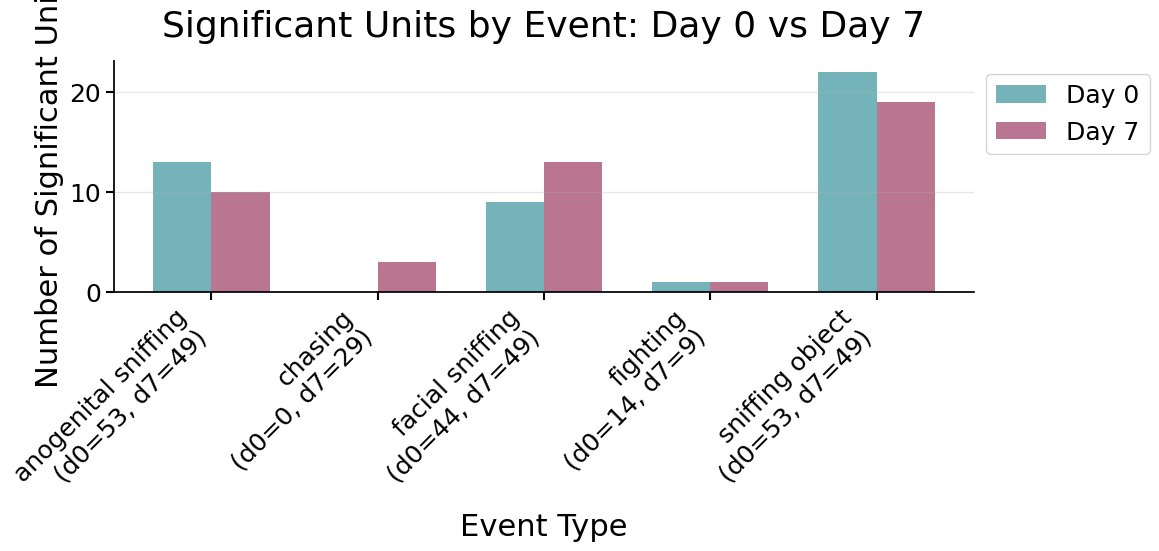


Percentage Change in Significant Units (Day 7 vs Day 0):
anogenital sniffing           :  13 ->  10 ( -23.1%)
chasing                       :   0 ->   3 (N/A)
facial sniffing               :   9 ->  13 ( +44.4%)
fighting                      :   1 ->   1 (  +0.0%)
sniffing object               :  22 ->  19 ( -13.6%)


In [1418]:
# Visualize comparison of significant units by event
import matplotlib.pyplot as plt

if not df_d0.empty and not df_d7.empty:
    # Get counts of significant units per event
    sig_d0 = df_d0[df_d0['sig'] != 'not sig'].groupby('Event').size()
    sig_d7 = df_d7[df_d7['sig'] != 'not sig'].groupby('Event').size()
    
    # Get total units tested per event for each day
    total_d0 = df_d0.groupby('Event').size()
    total_d7 = df_d7.groupby('Event').size()
    
    # Combine data for plotting
    events = sorted(set(sig_d0.index) | set(sig_d7.index))
    d0_counts = [sig_d0.get(e, 0) for e in events]
    d7_counts = [sig_d7.get(e, 0) for e in events]
    
    # Get total units for each event per day
    d0_totals = [total_d0.get(e, 0) for e in events]
    d7_totals = [total_d7.get(e, 0) for e in events]
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Transparent background
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    x = np.arange(len(events))
    width = 0.35
    
    ax.bar(x - width/2, d0_counts, width, label='Day 0', alpha=0.8, color=COLOR_DAY0)
    ax.bar(x + width/2, d7_counts, width, label='Day 7', alpha=0.8, color=COLOR_DAY7)
    
    ax.set_xlabel('Event Type', fontsize=22)
    ax.set_ylabel('Number of Significant Units', fontsize=22)
    ax.set_title('Significant Units by Event: Day 0 vs Day 7', fontsize=26, pad=18)
    ax.set_xticks(x)
    # Add total units per day in parentheses to each label
    event_labels = [f"{event}\n(d0={n0}, d7={n7})" for event, n0, n7 in zip(events, d0_totals, d7_totals)]
    ax.set_xticklabels(event_labels, rotation=45, ha='right', fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=18)
    
    # Apply seaborn despine and grid styling
    sns.despine(ax=ax)
    ax.grid(axis='y', alpha=0.3, linewidth=1)
    ax.tick_params(width=1.5, length=6)
    
    plt.tight_layout()
    plt.show()
    
    # Print percentage changes
    print("\nPercentage Change in Significant Units (Day 7 vs Day 0):")
    print("="*60)
    for event in events:
        d0_n = sig_d0.get(event, 0)
        d7_n = sig_d7.get(event, 0)
        if d0_n > 0:
            pct_change = ((d7_n - d0_n) / d0_n) * 100
            print(f"{event:30s}: {d0_n:3d} -> {d7_n:3d} ({pct_change:+6.1f}%)")
        else:
            print(f"{event:30s}: {d0_n:3d} -> {d7_n:3d} (N/A)")
else:
    print("Cannot compare - missing d0 or d7 data")

### Compare FPR with Real Event Response Rates

This visualization compares the false positive rate from random segments (tested above) with the actual response rates observed in real behavioral events (d0 and d7 data).

C:\Users\thoma\AppData\Local\Temp\ipykernel_42204\3626794000.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=10)
C:\Users\thoma\AppData\Local\Temp\ipykernel_42204\3626794000.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=10)


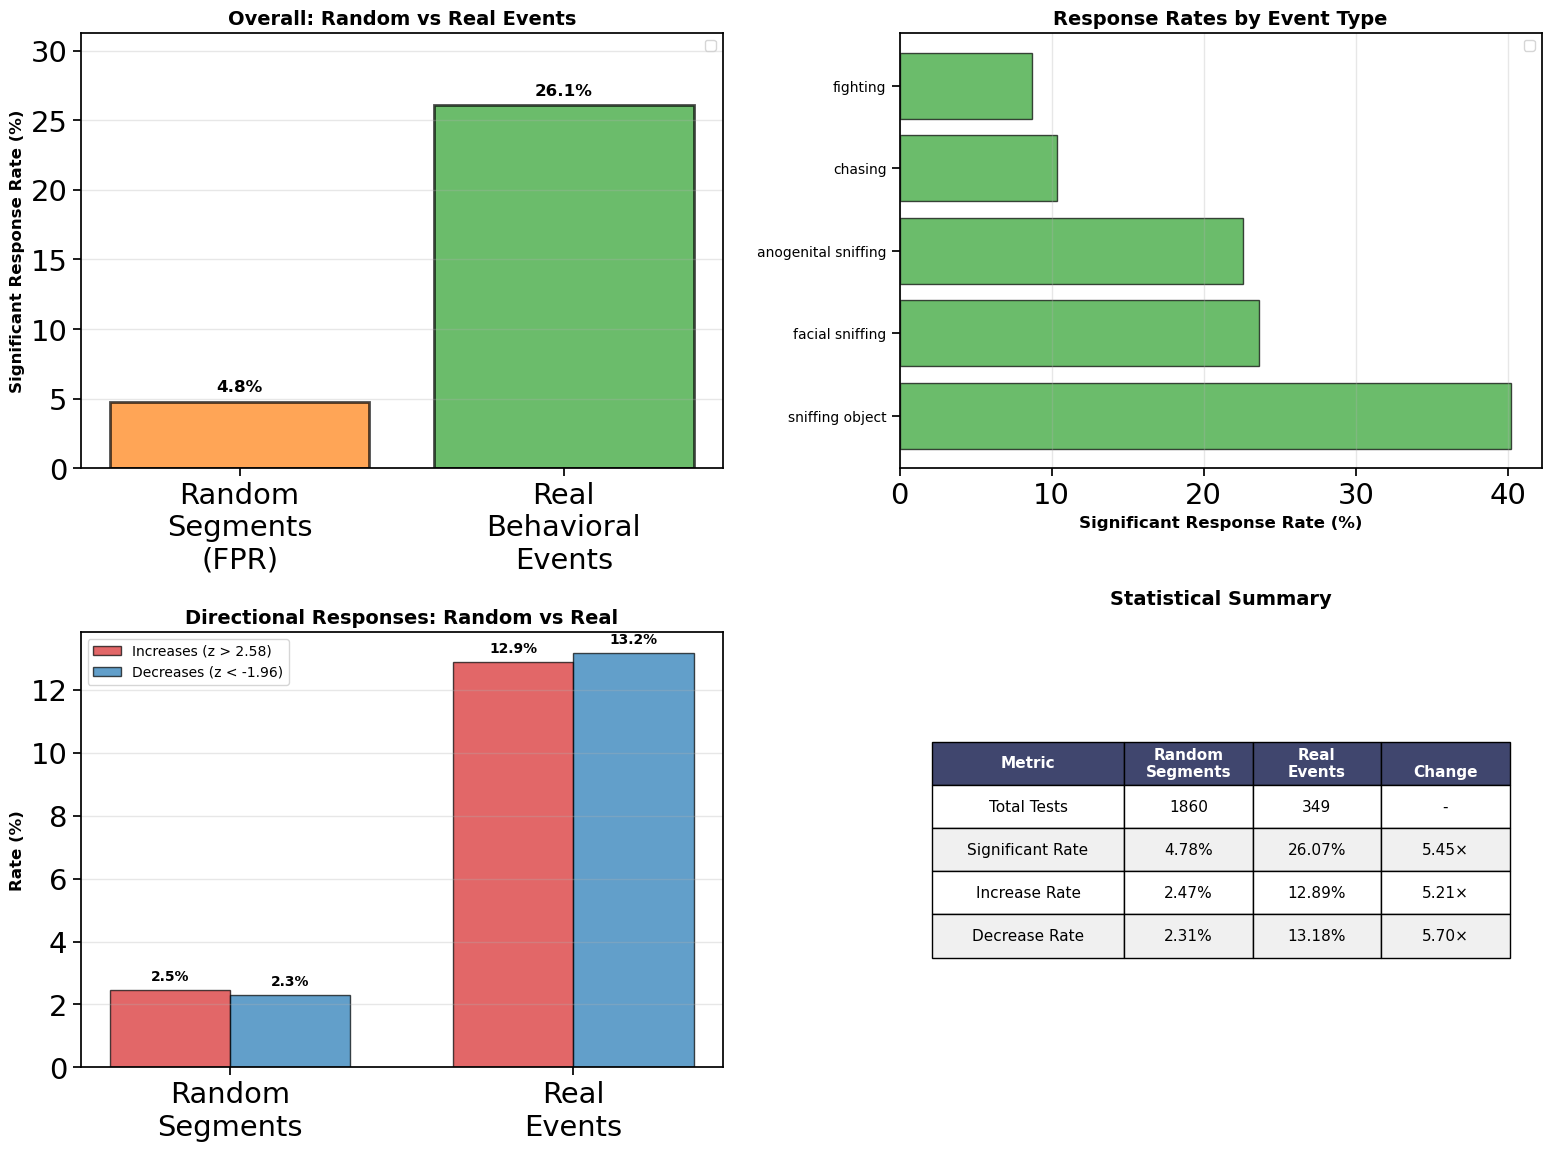


DETAILED COMPARISON: FALSE POSITIVE RATE vs REAL EVENT RESPONSES

Random Segments (FPR baseline):
  Total tests: 1860
  Significant rate: 4.78%
  - Increases: 2.47%
  - Decreases: 2.31%

Real Behavioral Events:
  Total tests: 349
  Significant rate: 26.07%
  - Increases: 12.89%
  - Decreases: 13.18%

Fold change (Real / Random):
  Overall: 5.45× higher than chance
  Increases: 5.21×
  Decreases: 5.70×

RESPONSE RATES BY EVENT TYPE
Event                        Total    Sig %    Inc %    Dec %     vs FPR
--------------------------------------------------------------------------------
sniffing object                102    40.2%    22.5%    17.6%      8.40×
facial sniffing                 93    23.7%    10.8%    12.9%      4.94×
anogenital sniffing            102    22.5%     6.9%    15.7%      4.71×
chasing                         29    10.3%    10.3%     0.0%      2.16×
fighting                        23     8.7%     8.7%     0.0%      1.82×


In [1419]:
# Compare False Positive Rate (FPR) from random segments with real behavioral event response rates

# Check if we have both FPR results and real data
if 'all_test_results' not in locals() or not all_test_results:
    print("⚠️ WARNING: FPR test results not found!")
    print("Please run the 'RIGOROUS FALSE POSITIVE RATE TEST' cell above first.")
elif df_d0.empty and df_d7.empty:
    print("⚠️ WARNING: No d0 or d7 data found!")
    print("Please run the day-by-day analysis cells above first.")
else:
    # Calculate FPR from test
    test_fpr = sum(1 for r in all_test_results if r['sig'] != 'not sig') / len(all_test_results) * 100
    test_increase_rate = sum(1 for r in all_test_results if r['sig'] == 'increase') / len(all_test_results) * 100
    test_decrease_rate = sum(1 for r in all_test_results if r['sig'] == 'decrease') / len(all_test_results) * 100
    
    # Calculate response rates for real behavioral events (combining d0 and d7)
    if not df_d7.empty:
        df_all_real = pd.concat([df_d0, df_d7], ignore_index=True)
    else:
        df_all_real = df_d0.copy()
    
    # Calculate per-event response rates
    event_stats = []
    for event_name in df_all_real['Event'].unique():
        event_data = df_all_real[df_all_real['Event'] == event_name]
        total = len(event_data)
        sig_count = (event_data['sig'] != 'not sig').sum()
        increase_count = (event_data['sig'] == 'increase').sum()
        decrease_count = (event_data['sig'] == 'decrease').sum()
        
        event_stats.append({
            'Event': event_name,
            'Total': total,
            'Significant_Rate': sig_count / total * 100 if total > 0 else 0,
            'Increase_Rate': increase_count / total * 100 if total > 0 else 0,
            'Decrease_Rate': decrease_count / total * 100 if total > 0 else 0
        })
    
    event_stats_df = pd.DataFrame(event_stats).sort_values('Significant_Rate', ascending=False)
    
    # Create comparison visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Overall response rates comparison
    ax1 = axes[0, 0]
    categories = ['Random\nSegments\n(FPR)', 'Real\nBehavioral\nEvents']
    overall_real_rate = (df_all_real['sig'] != 'not sig').sum() / len(df_all_real) * 100
    heights = [test_fpr, overall_real_rate]
    colors = ['#ff7f0e', '#2ca02c']
    bars = ax1.bar(categories, heights, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Significant Response Rate (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Overall: Random vs Real Events', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, max(heights) * 1.2)
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, height in zip(bars, heights):
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Plot 2: Response rates by event type
    ax2 = axes[0, 1]
    x_pos = np.arange(len(event_stats_df))
    ax2.barh(x_pos, event_stats_df['Significant_Rate'], color='#2ca02c', alpha=0.7, edgecolor='black')
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(event_stats_df['Event'], fontsize=10)
    ax2.set_xlabel('Significant Response Rate (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Response Rates by Event Type', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(axis='x', alpha=0.3)
    
    # Plot 3: Increase vs Decrease breakdown
    ax3 = axes[1, 0]
    x = np.arange(2)
    width = 0.35
    increase_vals = [test_increase_rate, (df_all_real['sig'] == 'increase').sum() / len(df_all_real) * 100]
    decrease_vals = [test_decrease_rate, (df_all_real['sig'] == 'decrease').sum() / len(df_all_real) * 100]
    
    bars1 = ax3.bar(x - width/2, increase_vals, width, label='Increases (z > 2.58)', 
                    color='#d62728', alpha=0.7, edgecolor='black')
    bars2 = ax3.bar(x + width/2, decrease_vals, width, label='Decreases (z < -1.96)', 
                    color='#1f77b4', alpha=0.7, edgecolor='black')
    
    ax3.set_ylabel('Rate (%)', fontsize=12, fontweight='bold')
    ax3.set_title('Directional Responses: Random vs Real', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(['Random\nSegments', 'Real\nEvents'])
    ax3.legend(fontsize=10)
    ax3.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 4: Summary table
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    # Create summary table
    summary_data = [
        ['Metric', 'Random\nSegments', 'Real\nEvents', '\nChange'],
        ['Total Tests', f'{len(all_test_results)}', f'{len(df_all_real)}', '-'],
        ['Significant Rate', f'{test_fpr:.2f}%', f'{overall_real_rate:.2f}%', 
         f'{overall_real_rate/test_fpr:.2f}×' if test_fpr > 0 else '-'],
        ['Increase Rate', f'{test_increase_rate:.2f}%', 
         f'{(df_all_real["sig"] == "increase").sum() / len(df_all_real) * 100:.2f}%',
         f'{((df_all_real["sig"] == "increase").sum() / len(df_all_real) * 100)/test_increase_rate:.2f}×' if test_increase_rate > 0 else '-'],
        ['Decrease Rate', f'{test_decrease_rate:.2f}%', 
         f'{(df_all_real["sig"] == "decrease").sum() / len(df_all_real) * 100:.2f}%',
         f'{((df_all_real["sig"] == "decrease").sum() / len(df_all_real) * 100)/test_decrease_rate:.2f}×' if test_decrease_rate > 0 else '-']
    ]
    
    table = ax4.table(cellText=summary_data, cellLoc='center', loc='center',
                      colWidths=[0.3, 0.2, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.5)
    
    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(summary_data)):
        for j in range(4):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#f0f0f0')
    
    ax4.set_title('Statistical Summary', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison
    print("\n" + "="*80)
    print("DETAILED COMPARISON: FALSE POSITIVE RATE vs REAL EVENT RESPONSES")
    print("="*80)
    print(f"\nRandom Segments (FPR baseline):")
    print(f"  Total tests: {len(all_test_results)}")
    print(f"  Significant rate: {test_fpr:.2f}%")
    print(f"  - Increases: {test_increase_rate:.2f}%")
    print(f"  - Decreases: {test_decrease_rate:.2f}%")
    
    print(f"\nReal Behavioral Events:")
    print(f"  Total tests: {len(df_all_real)}")
    print(f"  Significant rate: {overall_real_rate:.2f}%")
    print(f"  - Increases: {(df_all_real['sig'] == 'increase').sum() / len(df_all_real) * 100:.2f}%")
    print(f"  - Decreases: {(df_all_real['sig'] == 'decrease').sum() / len(df_all_real) * 100:.2f}%")
    
    if test_fpr > 0:
        print(f"\nFold change (Real / Random):")
        print(f"  Overall: {overall_real_rate/test_fpr:.2f}× higher than chance")
        if test_increase_rate > 0:
            print(f"  Increases: {((df_all_real['sig'] == 'increase').sum() / len(df_all_real) * 100)/test_increase_rate:.2f}×")
        if test_decrease_rate > 0:
            print(f"  Decreases: {((df_all_real['sig'] == 'decrease').sum() / len(df_all_real) * 100)/test_decrease_rate:.2f}×")
    
    print(f"\n{'='*80}")
    print("RESPONSE RATES BY EVENT TYPE")
    print("="*80)
    print(f"{'Event':<25s} {'Total':>8s} {'Sig %':>8s} {'Inc %':>8s} {'Dec %':>8s} {'vs FPR':>10s}")
    print("-"*80)
    for _, row in event_stats_df.iterrows():
        fold_vs_fpr = row['Significant_Rate'] / test_fpr if test_fpr > 0 else 0
        print(f"{row['Event']:<25s} {row['Total']:>8d} {row['Significant_Rate']:>7.1f}% "
              f"{row['Increase_Rate']:>7.1f}% {row['Decrease_Rate']:>7.1f}% {fold_vs_fpr:>9.2f}×")

### More Conservative Threshold Option (Optional)

If the FPR is still elevated, you can use more stringent z-score thresholds. The function below modifies the significance thresholds to use:
- **z > 3.0** for increases (p < 0.0013, ~0.13% one-tailed) - more conservative than original 2.58
- **z < -3.0** for decreases (p < 0.0013, ~0.13% one-tailed) - more conservative than original -1.96

This should reduce FPR to well below 1%.

In [1420]:
def poisson_event_test_conservative(recording, event_name, equalize=None, sides='two-sided', 
                                   z_threshold_increase=3.0, z_threshold_decrease=-3.0):
    """
    Same as poisson_event_test but with customizable z-score thresholds for more conservative testing.
    
    Parameters:
    - z_threshold_increase: Z-score threshold for significant increases (default 3.0, p < 0.0013)
    - z_threshold_decrease: Z-score threshold for significant decreases (default -3.0, p < 0.0013)
    """
    sr = recording.sampling_rate
    
    # Get good units
    good_units = getattr(recording, "good_units", None)
    if good_units is None:
        if hasattr(recording, 'labels_dict'):
            good_units = [unit_id for unit_id, label in recording.labels_dict.items() if label == "good"]
        else:
            good_units = [unit for unit, ts in recording.unit_timestamps.items() if len(ts) > 0]
    
    rec_gunits = {unit: recording.unit_timestamps[unit] for unit in good_units 
                  if unit in recording.unit_timestamps and len(recording.unit_timestamps[unit]) > 0}
    
    # Calculate recording duration and global rates
    max_timestamp = 0
    counts_all = {}
    
    for unit, ts in rec_gunits.items():
        counts_all[unit] = len(ts)
        if len(ts) > 0:
            max_timestamp = max(max_timestamp, ts[-1])
    
    T_all = max_timestamp / sr if max_timestamp > 0 else 1.0
    lam_global = {u: counts_all[u] / T_all for u in counts_all}
    
    # Calculate Fano factors
    fano_factors = {}
    bin_size_s = 1.0
    n_bins = int(np.ceil(T_all / bin_size_s))
    
    for unit, ts in rec_gunits.items():
        spike_times_s = ts / sr
        counts_per_bin = np.histogram(spike_times_s, bins=n_bins, range=(0, T_all))[0]
        mean_count = np.mean(counts_per_bin)
        if mean_count > 0:
            var_count = np.var(counts_per_bin)
            F = var_count / mean_count
            fano_factors[unit] = max(1.0, F)
        else:
            fano_factors[unit] = 1.0

    events = recording.event_dict[event_name]
    results = []
    
    for unit, ts in rec_gunits.items():
        spike_ms = ts * (1000.0 / sr)
        N = 0
        T = 0.0
        
        for start_ms, stop_ms in events:
            if equalize is not None:
                stop_ms = min(stop_ms, start_ms + 1000*equalize)
            i0 = np.searchsorted(spike_ms, start_ms, side='left')
            i1 = np.searchsorted(spike_ms, stop_ms, side='right')
            N += (i1 - i0)
            T += (stop_ms - start_ms) / 1000.0

        if T <= 0 or lam_global[unit] <= 0:
            continue

        FR_event = N / T if T > 0 else 0
        mu = lam_global[unit] * T
        F = fano_factors[unit]
        z = (N - mu) / np.sqrt(F * mu)
        
        if sides == 'two-sided':
            p = 2 * norm.sf(abs(z))
        elif sides == 'greater':
            p = norm.sf(z)
        else:
            p = norm.cdf(z)

        # Use custom thresholds
        results.append({
            "Recording": recording.name,
            "Event": event_name,
            "Unit": unit,
            "T_event_s": T,
            "N_event": N,
            "FR_event_Hz": FR_event,
            "lambda_global": lam_global[unit],
            "Fano_factor": fano_factors[unit],
            "z": z,
            "p": p,
            "sig": ("increase" if (sides!='less' and z > z_threshold_increase)
                    else "decrease" if (sides!='greater' and z < z_threshold_decrease)
                    else "not sig"),
            "threshold_increase": z_threshold_increase,
            "threshold_decrease": z_threshold_decrease
        })
    return results

print("✓ Conservative threshold function loaded")
print(f"  Default: z > 3.0 (increases), z < -3.0 (decreases)")
print(f"  Expected FPR: ~0.27% (much more stringent than 3%)")

✓ Conservative threshold function loaded
  Default: z > 3.0 (increases), z < -3.0 (decreases)
  Expected FPR: ~0.27% (much more stringent than 3%)


### Test Conservative Thresholds with FPR Test (Optional)

Run the same false positive rate test but with z > 3.0 / z < -3.0 thresholds to see if it improves FPR.

In [1421]:
# Test conservative thresholds (z > 3.0 / z < -3.0) on random segments
if 'all_test_results' not in locals() or not all_test_results:
    print("⚠️ WARNING: Original FPR test results not found!")
    print("Please run the 'RIGOROUS FALSE POSITIVE RATE TEST' cell above first.")
else:
    print("="*80)
    print("CONSERVATIVE THRESHOLD FPR TEST (z > 3.0 / z < -3.0)")
    print("="*80)
    print("Testing if more stringent thresholds reduce false positive rate.\n")
    print("Using event-type-specific durations (same as main FPR test).\n")
    
    n_iterations = 20
    conservative_test_results = []
    
    # Use same recordings as before
    test_recordings = sc.recordings[:min(5, len(sc.recordings))]
    
    for test_rec in test_recordings:
        sr = test_rec.sampling_rate
        max_timestamp = max(max(ts) if len(ts) > 0 else 0 
                            for ts in test_rec.unit_timestamps.values())
        rec_duration_ms = (max_timestamp / sr) * 1000
        
        if not test_rec.event_dict:
            continue
        real_event = list(test_rec.event_dict.keys())[0]
        real_windows = test_rec.event_dict[real_event]
        
        # Get event durations for this event type (for sampling)
        if real_event not in event_durations_by_type or len(event_durations_by_type[real_event]) == 0:
            print(f"  Skipping {test_rec.name}: no duration data for {real_event}")
            continue
        event_durations_pool = event_durations_by_type[real_event]
        
        print(f"Testing: {test_rec.name} ({len(real_windows)} windows, event: {real_event})")
        
        for iteration in range(n_iterations):
            np.random.seed(None)
            fake_events = []
            
            attempts = 0
            max_attempts = len(real_windows) * 20
            
            while len(fake_events) < len(real_windows) and attempts < max_attempts:
                # Sample a duration from the real event type's duration distribution
                sampled_duration_ms = np.random.choice(event_durations_pool)
                
                max_start = rec_duration_ms - sampled_duration_ms - 1000
                if max_start <= 0:
                    attempts += 1
                    continue
                
                random_start = np.random.uniform(0, max_start)
                random_end = random_start + sampled_duration_ms
                
                overlaps = False
                for existing_start, existing_end in fake_events:
                    if not (random_end < existing_start or random_start > existing_end):
                        overlaps = True
                        break
                
                if not overlaps:
                    fake_events.append([random_start, random_end])
                attempts += 1
            
            test_rec.event_dict['fake_event'] = fake_events
            
            # Use conservative thresholds with variable durations (equalize=None)
            results = poisson_event_test_conservative(test_rec, 'fake_event', equalize=None,
                                                      z_threshold_increase=3.0, z_threshold_decrease=-3.0)
            
            if results:
                conservative_test_results.extend(results)
            
            del test_rec.event_dict['fake_event']
    
    # Compare original vs conservative thresholds
    if conservative_test_results:
        cons_n_sig = sum(1 for r in conservative_test_results if r['sig'] != 'not sig')
        cons_total = len(conservative_test_results)
        cons_fpr = cons_n_sig / cons_total
        
        print(f"\n{'='*80}")
        print(f"RESULTS COMPARISON: ORIGINAL vs CONSERVATIVE THRESHOLDS")
        print(f"{'='*80}")
        
        # Original results
        orig_n_sig = sum(1 for r in all_test_results if r['sig'] != 'not sig')
        orig_total = len(all_test_results)
        orig_fpr = orig_n_sig / orig_total
        
        print(f"\nOriginal Thresholds (z > 2.58 / z < -1.96):")
        print(f"  Total tests: {orig_total}")
        print(f"  Significant: {orig_n_sig} ({orig_fpr*100:.2f}%)")
        print(f"  Expected FPR: ~3.0%")
        
        print(f"\nConservative Thresholds (z > 3.0 / z < -3.0):")
        print(f"  Total tests: {cons_total}")
        print(f"  Significant: {cons_n_sig} ({cons_fpr*100:.2f}%)")
        print(f"  Expected FPR: ~0.27%")
        
        if orig_fpr > 0:
            reduction = (1 - cons_fpr/orig_fpr) * 100
            print(f"\nFPR Reduction: {reduction:.1f}%")
        
        # Statistical test
        try:
            from scipy.stats import binomtest
            p_value_cons = binomtest(cons_n_sig, cons_total, 0.0027, alternative='greater').pvalue
            print(f"\nBinomial test (H0: FPR = 0.27%):")
            print(f"  p-value = {p_value_cons:.4f}")
            
            if cons_fpr < 0.01:
                print("\n✓✓ EXCELLENT: FPR < 1% with conservative thresholds!")
            elif cons_fpr < 0.03:
                print("\n✓ GOOD: FPR < 3% with conservative thresholds")
            else:
                print("\n⚠️ FPR still elevated, but improved")
        except:
            pass
        
        print(f"\n{'='*80}")
        print("RECOMMENDATION")
        print("="*80)
        if cons_fpr < orig_fpr / 2:
            print("✓ Conservative thresholds substantially reduce FPR.")
            print("  Consider using z > 3.0 / z < -3.0 for your main analysis")
            print("  if you want to minimize false positives.")
        else:
            print("Original thresholds appear reasonable for your data.")
    else:
        print("No results generated")

CONSERVATIVE THRESHOLD FPR TEST (z > 3.0 / z < -3.0)
Testing if more stringent thresholds reduce false positive rate.

Using event-type-specific durations (same as main FPR test).

Testing: 22_rehouse_d0_merged.rec (19 windows, event: anogenital sniffing)
Testing: 22_rehouse_d7_merged.rec (11 windows, event: anogenital sniffing)
Testing: 32_rehouse_d0_merged.rec (4 windows, event: anogenital sniffing)
Testing: 32_rehouse_d7_merged.rec (22 windows, event: anogenital sniffing)
Testing: 32_rehouse_d7_merged.rec (22 windows, event: anogenital sniffing)
Testing: 41_rehouse_d0_merged.rec (27 windows, event: anogenital sniffing)

RESULTS COMPARISON: ORIGINAL vs CONSERVATIVE THRESHOLDS

Original Thresholds (z > 2.58 / z < -1.96):
  Total tests: 1860
  Significant: 89 (4.78%)
  Expected FPR: ~3.0%

Conservative Thresholds (z > 3.0 / z < -3.0):
  Total tests: 1240
  Significant: 83 (6.69%)
  Expected FPR: ~0.27%

FPR Reduction: -39.9%

Binomial test (H0: FPR = 0.27%):
  p-value = 0.0000

⚠️ FPR 

### Run Analysis on All Recordings

Execute the Poisson-based test across all recordings and behavioral events.

In [1422]:
# Run the Poisson-based analysis for all recordings and all behavioral events
# Set use_event_durations=True to use actual event durations (Option B)
behavioral_event_df, skipped = run_all_recordings_all_events_poisson(
    sc, 
    equalize=10,           # Only used if use_event_durations=False
    sides='two-sided',     # Test for increases or decreases
    alpha=0.05,            # Significance level
    verbose=True,          # Show processing details
    use_event_durations=True  # ← Use event-specific durations (Option B)
)

print(f"\n{'='*80}")
print(f"OVERALL SUMMARY")
print(f"{'='*80}")
print(f"DataFrame shape: {behavioral_event_df.shape}")
print(f"Skipped count: {skipped.shape[0]}")
print(f"\nSignificance counts:")
print(behavioral_event_df['sig'].value_counts())
print(f"\nFirst few rows:")
behavioral_event_df.head(10)

All event names: ['anogenital sniffing', 'chasing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object']
Using event-specific durations (variable duration windows)

Processing: 22_rehouse_d0_merged.rec
  anogenital sniffing: 14 units, 6 significant
  Skipping chasing: no windows
  facial sniffing: 14 units, 2 significant
  fighting: 14 units, 1 significant
  ERROR in mice back in: cannot convert float infinity to integer
  ERROR in mice taken out: cannot convert float infinity to integer
  sniffing object: 14 units, 8 significant

Processing: 22_rehouse_d7_merged.rec
  anogenital sniffing: 9 units, 2 significant
  Skipping chasing: no windows
  facial sniffing: 9 units, 3 significant
  fighting: 9 units, 1 significant
  ERROR in mice back in: cannot convert float infinity to integer
  ERROR in mice taken out: cannot convert float infinity to integer
  sniffing object: 9 units, 4 significant

Processing: 32_rehouse_d0_merged.rec
  anogenital sniffing: 9 un

C:\Users\thoma\AppData\Local\Temp\ipykernel_42204\3167010022.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  n_bins = int(np.floor(T_all / bin_size_s))  # Use floor to ensure full bins


,Recording,Event,Unit,T_event_s,N_event,FR_event_Hz,lambda_global,Fano_factor,z,p,sig
0,22_rehouse_d0_merged.rec,anogenital sniffing,13,41.08425,56,1.363053,4.255385,9.621481,-2.897313,0.003764,decrease
1,22_rehouse_d0_merged.rec,anogenital sniffing,14,41.08425,331,8.056615,8.295919,12.962741,-0.147913,0.882412,not sig
2,22_rehouse_d0_merged.rec,anogenital sniffing,25,41.08425,1,0.024340,0.124358,1.679537,-1.402762,0.160688,not sig
3,22_rehouse_d0_merged.rec,anogenital sniffing,26,41.08425,25,0.608506,3.645252,7.151819,-3.812187,0.000138,decrease
4,22_rehouse_d0_merged.rec,anogenital sniffing,27,41.08425,90,2.190620,3.238312,5.066256,-1.657937,0.097330,not sig
5,22_rehouse_d0_merged.rec,anogenital sniffing,3,41.08425,122,2.969508,2.184597,10.477761,1.051569,0.292997,not sig
6,22_rehouse_d0_merged.rec,anogenital sniffing,36,41.08425,351,8.543420,5.573361,15.929750,2.020411,0.043341,not sig
7,22_rehouse_d0_merged.rec,anogenital sniffing,55,41.08425,32,0.778887,0.611243,3.853651,0.700137,0.483842,not sig
8,22_rehouse_d0_merged.rec,anogenital sniffing,56,41.08425,31,0.754547,2.717561,5.723370,-3.190403,0.001421,decrease
9,22_rehouse_d0_merged.rec,anogenital sniffing,60,41.08425,89,2.166280,3.865100,9.503709,-1.796627,0.072395,not sig


### Explore Results

Summary statistics and exploration of significant units.

In [1423]:
# Summary statistics by event type
print("Summary by Event Type:")
print("="*80)
summary = behavioral_event_df.groupby('Event').agg({
    'Unit': 'count',
    'sig': lambda x: (x != 'not sig').sum(),
    'z': ['mean', 'std'],
    'p': 'mean',
    'lambda_global': 'mean'
}).round(3)
summary.columns = ['Total Units', 'Significant Units', 'Mean Z-Score', 'Std Z-Score', 'Mean p-value', 'Mean λ (Hz)']
summary

Summary by Event Type:


,Total Units,Significant Units,Mean Z-Score,Std Z-Score,Mean p-value,Mean λ (Hz)
Event,,,,,,
anogenital sniffing,102,23,-0.190,2.161,0.309,3.375
chasing,29,3,-0.094,1.560,0.401,3.130
facial sniffing,93,22,-0.102,1.982,0.337,3.434
fighting,23,2,0.221,1.852,0.426,3.931
sniffing object,102,41,0.385,2.966,0.226,3.375


SOCIAL BEHAVIORS


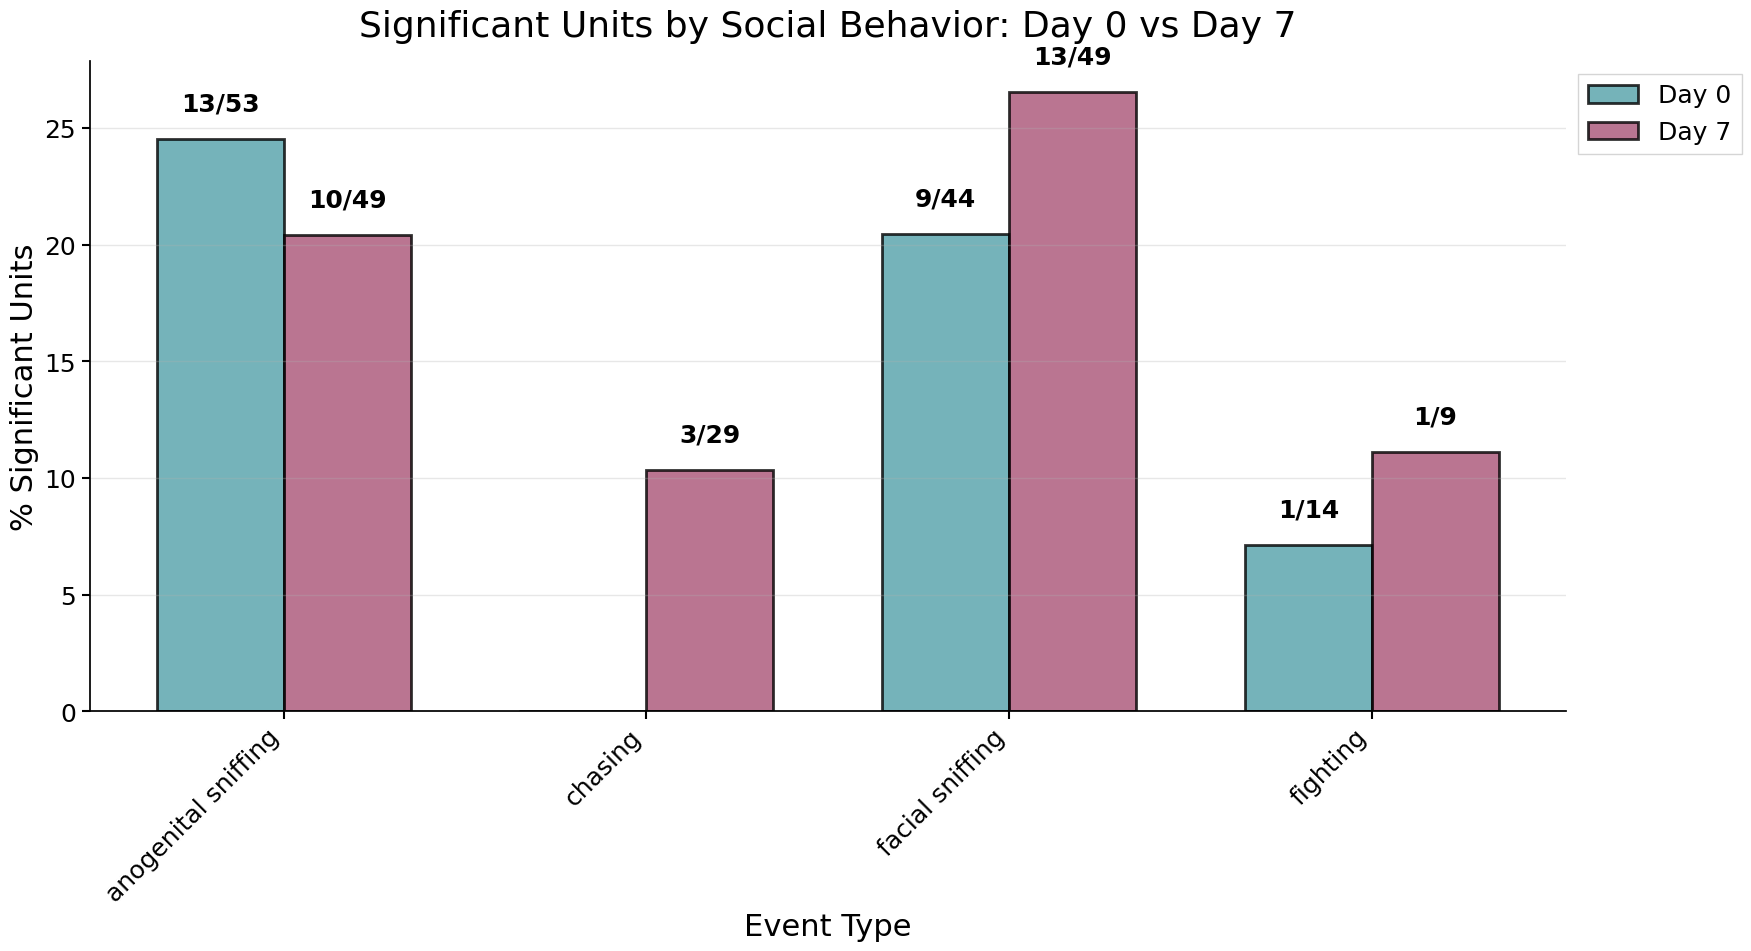


OBJECT BEHAVIOR


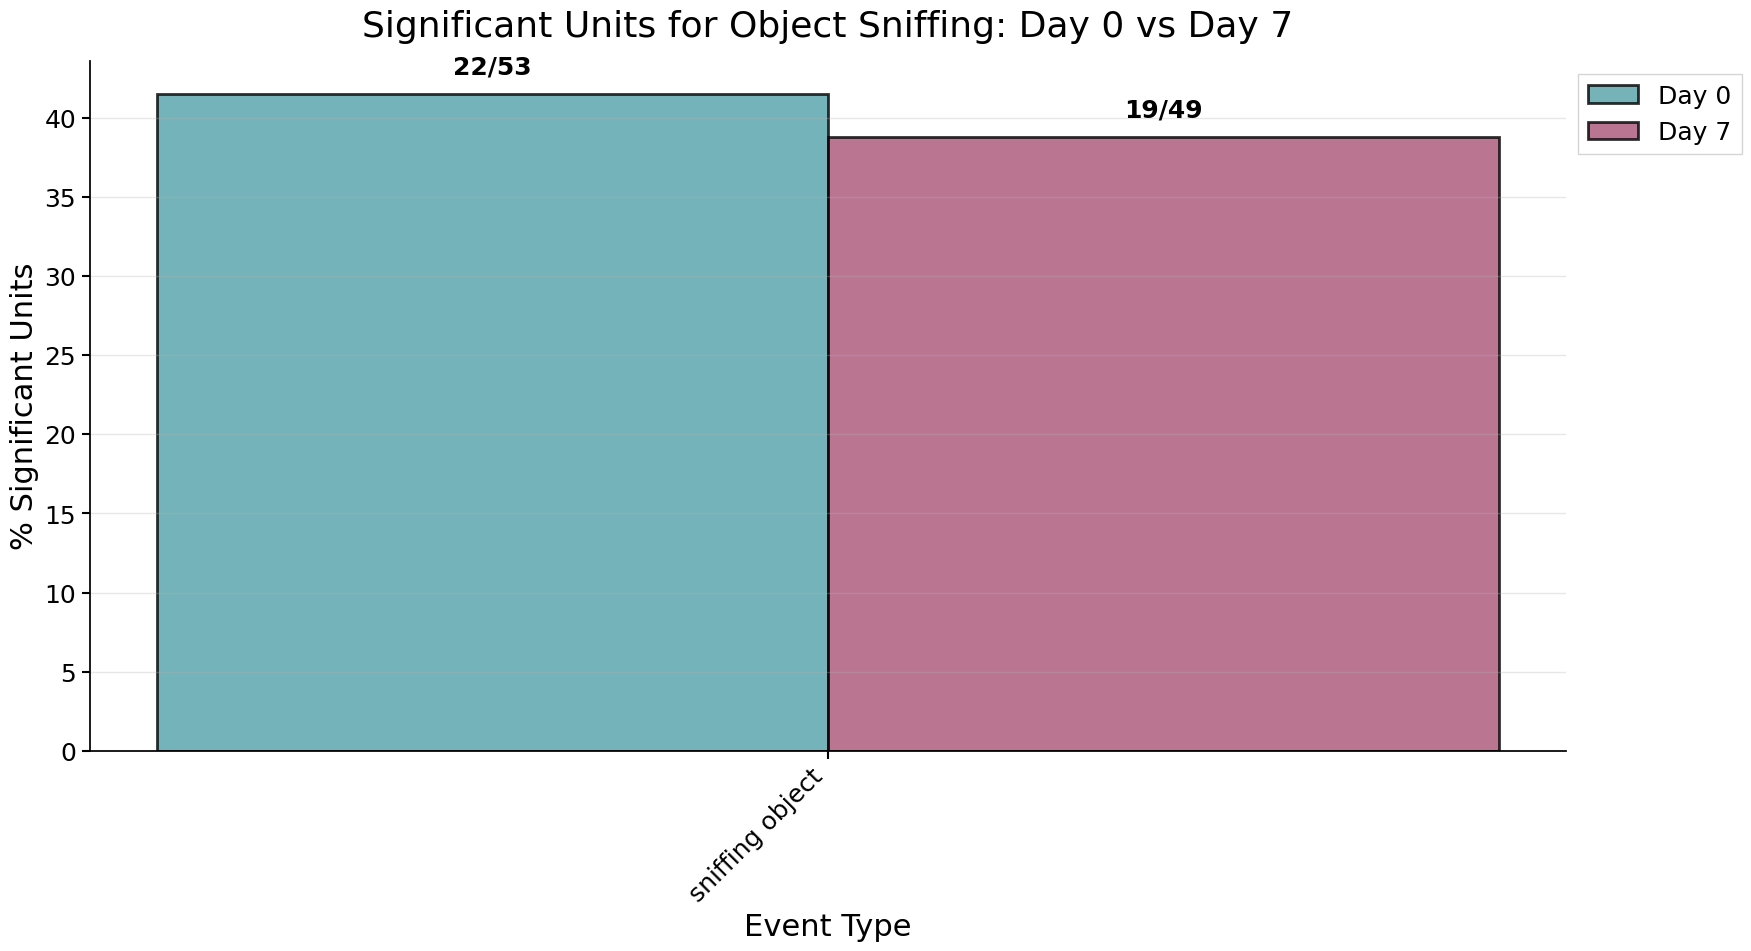


DETAILED SUMMARY: UNITS TESTED AND SIGNIFICANT UNITS BY EVENT TYPE AND DAY
Event                               Day   Total Units     Sig Units       % Sig     
----------------------------------------------------------------------------------------------------
anogenital sniffing                 d0    53              13                24.5%
anogenital sniffing                 d7    49              10                20.4%

chasing                             d0    0               0                  0.0%
chasing                             d7    29              3                 10.3%

facial sniffing                     d0    44              9                 20.5%
facial sniffing                     d7    49              13                26.5%

fighting                            d0    14              1                  7.1%
fighting                            d7    9               1                 11.1%

sniffing object                     d0    53              22                41

In [1442]:
# Bar plot: Number of significant units per event type, separated by d0 and d7
# Calculate statistics for d0
sig_by_event_d0 = df_d0[df_d0['sig'] != 'not sig'].groupby('Event').size()
total_by_event_d0 = df_d0.groupby('Event').size()

# Calculate statistics for d7
sig_by_event_d7 = df_d7[df_d7['sig'] != 'not sig'].groupby('Event').size()
total_by_event_d7 = df_d7.groupby('Event').size()

# Get all unique events from both days
all_events = sorted(set(total_by_event_d0.index) | set(total_by_event_d7.index))

# Separate social behaviors from object sniffing
social_events = [e for e in all_events if e != 'sniffing object']
object_events = [e for e in all_events if e == 'sniffing object']

# Function to create plot for a set of events
def create_event_plot(events_to_plot, title_suffix):
    if not events_to_plot:
        return
    
    # Prepare data for plotting
    d0_sig_counts = [sig_by_event_d0.get(event, 0) for event in events_to_plot]
    d0_total_counts = [total_by_event_d0.get(event, 0) for event in events_to_plot]
    d7_sig_counts = [sig_by_event_d7.get(event, 0) for event in events_to_plot]
    d7_total_counts = [total_by_event_d7.get(event, 0) for event in events_to_plot]
    
    # Create side-by-side bar plot with new styling
    fig, ax = plt.subplots(figsize=(18, 10))
    
    # Transparent background
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    x = np.arange(len(events_to_plot))
    
    # Adjust bar width based on number of events (narrower for single event)
    if len(events_to_plot) == 1:
        width = 0.12  # Much narrower for single event (about 1/3 of default)
    else:
        width = 0.35  # Default width for multiple events
    
    # Calculate percentages
    d0_percent = [(sig/total*100 if total > 0 else 0) for sig, total in zip(d0_sig_counts, d0_total_counts)]
    d7_percent = [(sig/total*100 if total > 0 else 0) for sig, total in zip(d7_sig_counts, d7_total_counts)]
    
    # Create bars with new colors
    bars1 = ax.bar(x - width/2, d0_percent, width, label='Day 0', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY0)
    bars2 = ax.bar(x + width/2, d7_percent, width, label='Day 7', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY7)
    
    # Font sizes according to style guide
    ax.set_ylabel('% Significant Units', fontsize=22)
    ax.set_xlabel('Event Type', fontsize=22)
    ax.set_title(f'{title_suffix}: Day 0 vs Day 7', fontsize=26, pad=18)
    
    # Clean up x-axis labels (remove parentheses and make them more readable)
    clean_event_labels = []
    for event in events_to_plot:
        # Remove any parentheses in the event names
        clean_label = event.replace('(', '').replace(')', '')
        clean_event_labels.append(clean_label)
    
    ax.set_xticks(x)
    ax.set_xticklabels(clean_event_labels, rotation=45, ha='right', fontsize=18)
    ax.tick_params(axis='y', labelsize=18, width=1.5, length=6)
    ax.tick_params(axis='x', width=1.5, length=6)
    
    # Legend positioned outside plot area
    ax.legend(fontsize=18, frameon=True, fancybox=False, 
              loc='upper left', bbox_to_anchor=(1.0, 1.0))
    
    # Apply seaborn despine and grid styling
    sns.despine(ax=ax)
    ax.grid(axis='y', alpha=0.3, linewidth=1)
    
    # Add count labels on bars
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        # d0 labels
        if d0_total_counts[i] > 0:
            height1 = bar1.get_height()
            ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 1,
                    f'{d0_sig_counts[i]}/{d0_total_counts[i]}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')
        
        # d7 labels
        if d7_total_counts[i] > 0:
            height2 = bar2.get_height()
            ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 1,
                    f'{d7_sig_counts[i]}/{d7_total_counts[i]}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Create plot for social behaviors
print("="*100)
print("SOCIAL BEHAVIORS")
print("="*100)
create_event_plot(social_events, 'Significant Units by Social Behavior')

# Create plot for object sniffing
print("\n" + "="*100)
print("OBJECT BEHAVIOR")
print("="*100)
create_event_plot(object_events, 'Significant Units for Object Sniffing')

# Print detailed summary table
print("\n" + "="*100)
print("DETAILED SUMMARY: UNITS TESTED AND SIGNIFICANT UNITS BY EVENT TYPE AND DAY")
print("="*100)
print(f"{'Event':<35} {'Day':<5} {'Total Units':<15} {'Sig Units':<15} {'% Sig':<10}")
print("-"*100)

for event in all_events:
    # d0 stats
    d0_total = total_by_event_d0.get(event, 0)
    d0_sig = sig_by_event_d0.get(event, 0)
    d0_pct = (d0_sig / d0_total * 100) if d0_total > 0 else 0
    print(f"{event:<35} {'d0':<5} {d0_total:<15} {d0_sig:<15} {d0_pct:>6.1f}%")
    
    # d7 stats
    d7_total = total_by_event_d7.get(event, 0)
    d7_sig = sig_by_event_d7.get(event, 0)
    d7_pct = (d7_sig / d7_total * 100) if d7_total > 0 else 0
    print(f"{event:<35} {'d7':<5} {d7_total:<15} {d7_sig:<15} {d7_pct:>6.1f}%")
    print()

print("="*100)

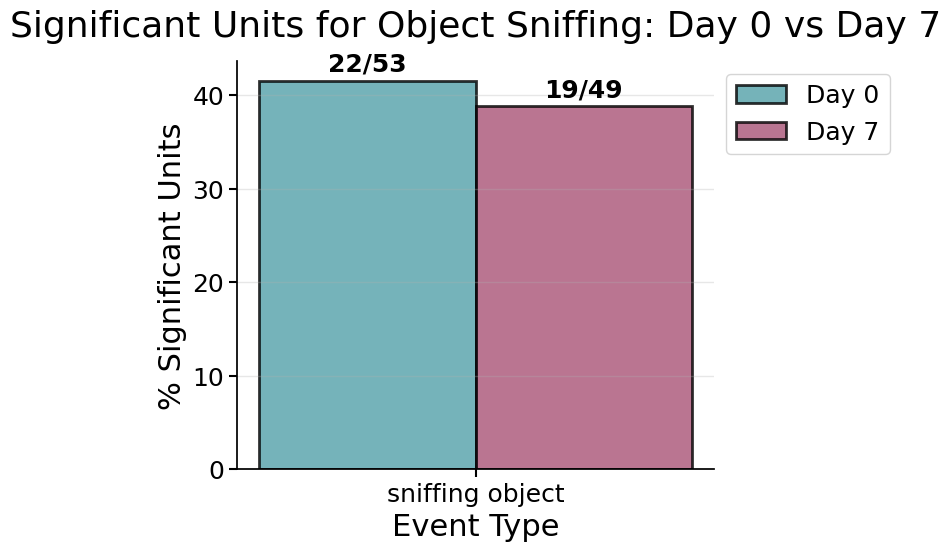

In [1443]:
def object_plot(events_to_plot, title_suffix):
    if not events_to_plot:
        return
    
    # Prepare data
    d0_sig_counts = [sig_by_event_d0.get(event, 0) for event in events_to_plot]
    d0_total_counts = [total_by_event_d0.get(event, 0) for event in events_to_plot]
    d7_sig_counts = [sig_by_event_d7.get(event, 0) for event in events_to_plot]
    d7_total_counts = [total_by_event_d7.get(event, 0) for event in events_to_plot]
    
    # Figure size tuned for 1–2 bars
    fig_width = 6 + 2 * len(events_to_plot)
    fig_height = 6
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Transparent background
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    x = np.arange(len(events_to_plot))
    width = 0.25 if len(events_to_plot) <= 2 else 0.35  # narrower if few bars
    
    # Calculate percentages
    d0_percent = [(sig/total*100 if total > 0 else 0) for sig, total in zip(d0_sig_counts, d0_total_counts)]
    d7_percent = [(sig/total*100 if total > 0 else 0) for sig, total in zip(d7_sig_counts, d7_total_counts)]
    
    # Bars with new colors
    bars1 = ax.bar(x - width/2, d0_percent, width, label='Day 0', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY0)
    bars2 = ax.bar(x + width/2, d7_percent, width, label='Day 7', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY7)
    
    # Labels and title with new font sizes
    ax.set_ylabel('% Significant Units', fontsize=22)
    ax.set_xlabel('Event Type', fontsize=22)
    ax.set_title(f'{title_suffix}: Day 0 vs Day 7', fontsize=26, pad=18)
    
    clean_labels = [event.replace('(', '').replace(')', '') for event in events_to_plot]
    ax.set_xticks(x)
    ax.set_xticklabels(clean_labels, fontsize=18)
    ax.tick_params(axis='y', labelsize=18, width=1.5, length=6)
    ax.tick_params(axis='x', width=1.5, length=6)
    
    # Legend positioned outside plot area
    ax.legend(fontsize=18, loc='upper left', bbox_to_anchor=(1.0, 1.0))
    
    # Apply seaborn despine and grid
    sns.despine(ax=ax)
    ax.grid(axis='y', alpha=0.3, linewidth=1)
    
    # Labels above bars
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        if d0_total_counts[i] > 0:
            ax.text(bar1.get_x() + bar1.get_width()/2., bar1.get_height() + 0.5,
                    f'{d0_sig_counts[i]}/{d0_total_counts[i]}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')
        if d7_total_counts[i] > 0:
            ax.text(bar2.get_x() + bar2.get_width()/2., bar2.get_height() + 0.5,
                    f'{d7_sig_counts[i]}/{d7_total_counts[i]}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

    plt.tight_layout()
    plt.show()

object_plot(object_events, 'Significant Units for Object Sniffing')

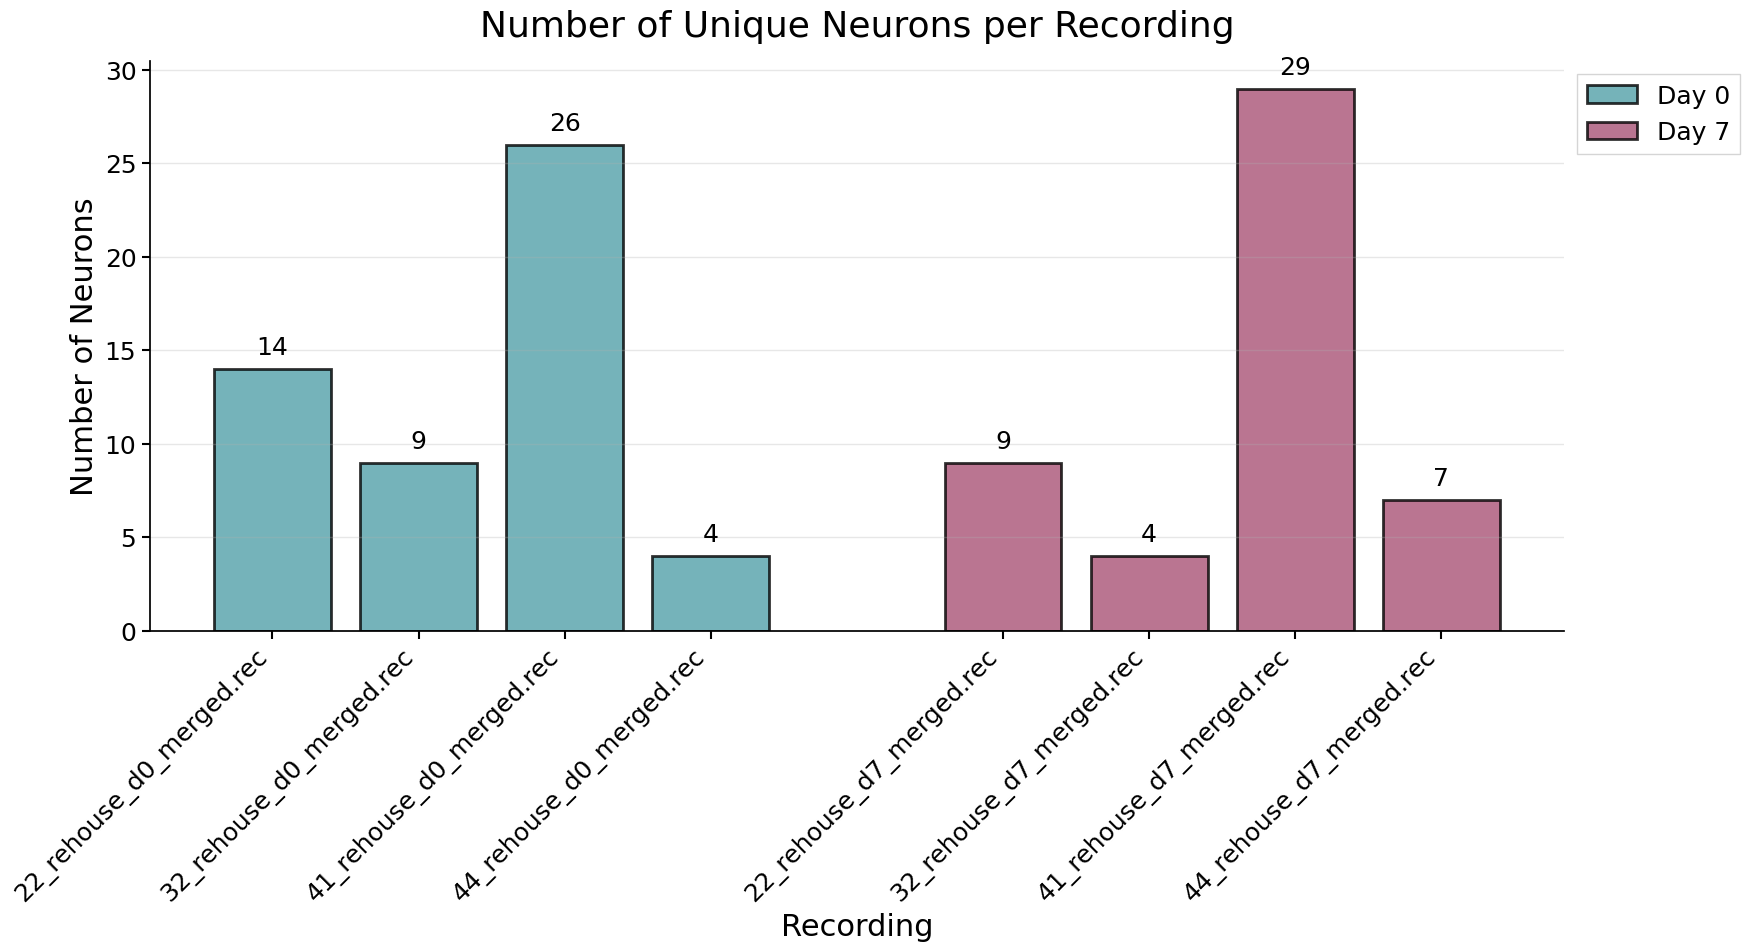


NEURON COUNT SUMMARY

Day 0 Recordings:
  Total neurons across all recordings:  53
  Mean neurons per recording:            13.2 ± 9.4
  Range:                                 4 - 26

Day 7 Recordings:
  Total neurons across all recordings:  49
  Mean neurons per recording:            12.2 ± 11.4
  Range:                                 4 - 29

Overall:
  Total unique neurons tested:           102
  Number of Day 0 recordings:            4
  Number of Day 7 recordings:            4


In [1426]:
# ============================================================================
# NUMBER OF UNIQUE NEURONS PER RECORDING
# ============================================================================

# Count unique units per recording for d0 and d7
recording_neuron_counts_d0 = []
recording_neuron_counts_d7 = []

# Get unique neurons from df_d0 and df_d7
if not df_d0.empty:
    for recording_name in df_d0['Recording'].unique():
        n_units = df_d0[df_d0['Recording'] == recording_name]['Unit'].nunique()
        recording_neuron_counts_d0.append({
            'Recording': recording_name,
            'N_Neurons': n_units,
            'Day': 'd0'
        })

if not df_d7.empty:
    for recording_name in df_d7['Recording'].unique():
        n_units = df_d7[df_d7['Recording'] == recording_name]['Unit'].nunique()
        recording_neuron_counts_d7.append({
            'Recording': recording_name,
            'N_Neurons': n_units,
            'Day': 'd7'
        })

# Combine into dataframe
neuron_counts_df = pd.DataFrame(recording_neuron_counts_d0 + recording_neuron_counts_d7)

# Create bar plot
fig, ax = plt.subplots(figsize=(18, 10))

# Transparent background
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')

# Separate d0 and d7 data
d0_data = neuron_counts_df[neuron_counts_df['Day'] == 'd0'].sort_values('Recording')
d7_data = neuron_counts_df[neuron_counts_df['Day'] == 'd7'].sort_values('Recording')

# Create x positions
recordings_d0 = d0_data['Recording'].tolist()
recordings_d7 = d7_data['Recording'].tolist()

x_d0 = np.arange(len(recordings_d0))
x_d7 = np.arange(len(recordings_d7)) + len(recordings_d0) + 1  # Add gap between d0 and d7

# Plot bars with new colors
bars_d0 = ax.bar(x_d0, d0_data['N_Neurons'], alpha=0.8, edgecolor='black', 
                  linewidth=2, label='Day 0', color=COLOR_DAY0)
bars_d7 = ax.bar(x_d7, d7_data['N_Neurons'], alpha=0.8, edgecolor='black', 
                  linewidth=2, label='Day 7', color=COLOR_DAY7)

# Styling with new font sizes
ax.set_ylabel('Number of Neurons', fontsize=22)
ax.set_xlabel('Recording', fontsize=22)
ax.set_title('Number of Unique Neurons per Recording', fontsize=26, pad=18)

# Set x-ticks and labels
all_x = np.concatenate([x_d0, x_d7])
all_labels = recordings_d0 + recordings_d7
ax.set_xticks(all_x)
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=18)
ax.tick_params(axis='y', labelsize=18, width=1.5, length=6)
ax.tick_params(axis='x', width=1.5, length=6)

# Legend positioned outside plot area
ax.legend(fontsize=18, frameon=True, fancybox=False, 
          loc='upper left', bbox_to_anchor=(1.0, 1.0))

# Apply seaborn despine and grid
sns.despine(ax=ax)
ax.grid(axis='y', alpha=0.3, linewidth=1)

# Add value labels on bars
for bars in [bars_d0, bars_d7]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=18, fontweight='normal')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*100)
print("NEURON COUNT SUMMARY")
print("="*100)

total_d0 = d0_data['N_Neurons'].sum()
total_d7 = d7_data['N_Neurons'].sum()
mean_d0 = d0_data['N_Neurons'].mean()
mean_d7 = d7_data['N_Neurons'].mean()
std_d0 = d0_data['N_Neurons'].std()
std_d7 = d7_data['N_Neurons'].std()

print(f"\nDay 0 Recordings:")
print(f"  Total neurons across all recordings:  {total_d0:,}")
print(f"  Mean neurons per recording:            {mean_d0:.1f} ± {std_d0:.1f}")
print(f"  Range:                                 {d0_data['N_Neurons'].min()} - {d0_data['N_Neurons'].max()}")

print(f"\nDay 7 Recordings:")
print(f"  Total neurons across all recordings:  {total_d7:,}")
print(f"  Mean neurons per recording:            {mean_d7:.1f} ± {std_d7:.1f}")
print(f"  Range:                                 {d7_data['N_Neurons'].min()} - {d7_data['N_Neurons'].max()}")

print(f"\nOverall:")
print(f"  Total unique neurons tested:           {total_d0 + total_d7:,}")
print(f"  Number of Day 0 recordings:            {len(recordings_d0)}")
print(f"  Number of Day 7 recordings:            {len(recordings_d7)}")
print("="*100)

In [1427]:
# Count event types for d0 and d7
print("="*80)
print("EVENT TYPE COUNTS BY DAY")
print("="*80)

# Count by event type for d0
print("\nD0 Event Type Counts:")
print("-"*80)
if not df_d0.empty:
    event_counts_d0 = df_d0.groupby('Event').size().sort_values(ascending=False)
    for event, count in event_counts_d0.items():
        print(f"  {event:30s}: {count:4d} unit-event observations")
    print(f"\n  Total d0 observations: {len(df_d0)}")
else:
    print("  No d0 data available")

# Count by event type for d7
print("\nD7 Event Type Counts:")
print("-"*80)
if not df_d7.empty:
    event_counts_d7 = df_d7.groupby('Event').size().sort_values(ascending=False)
    for event, count in event_counts_d7.items():
        print(f"  {event:30s}: {count:4d} unit-event observations")
    print(f"\n  Total d7 observations: {len(df_d7)}")
else:
    print("  No d7 data available")

# Compare side-by-side
print("\n" + "="*80)
print("SIDE-BY-SIDE COMPARISON")
print("="*80)
if not df_d0.empty and not df_d7.empty:
    # Get all unique events
    all_events = sorted(set(event_counts_d0.index) | set(event_counts_d7.index))
    
    print(f"\n{'Event':<30s} {'d0 Count':>10s} {'d7 Count':>10s} {'Difference':>12s}")
    print("-"*80)
    for event in all_events:
        d0_count = event_counts_d0.get(event, 0)
        d7_count = event_counts_d7.get(event, 0)
        diff = d7_count - d0_count
        diff_str = f"{diff:+d}" if diff != 0 else "0"
        print(f"{event:<30s} {d0_count:>10d} {d7_count:>10d} {diff_str:>12s}")
    
    print("-"*80)
    print(f"{'TOTAL':<30s} {len(df_d0):>10d} {len(df_d7):>10d} {len(df_d7)-len(df_d0):>+12d}")


EVENT TYPE COUNTS BY DAY

D0 Event Type Counts:
--------------------------------------------------------------------------------
  anogenital sniffing           :   53 unit-event observations
  sniffing object               :   53 unit-event observations
  facial sniffing               :   44 unit-event observations
  fighting                      :   14 unit-event observations

  Total d0 observations: 164

D7 Event Type Counts:
--------------------------------------------------------------------------------
  anogenital sniffing           :   49 unit-event observations
  facial sniffing               :   49 unit-event observations
  sniffing object               :   49 unit-event observations
  chasing                       :   29 unit-event observations
  fighting                      :    9 unit-event observations

  Total d7 observations: 185

SIDE-BY-SIDE COMPARISON

Event                            d0 Count   d7 Count   Difference
------------------------------------------------

BEHAVIORAL EVENT BOUTS - SOCIAL BEHAVIORS

Social behaviors:
  fighting: d0=4, d7=1, total=5
  anogenital sniffing: d0=68, d7=60, total=128
  facial sniffing: d0=52, d7=65, total=117
  chasing: d0=0, d7=4, total=4


C:\Users\thoma\AppData\Local\Temp\ipykernel_42204\2144663000.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(tick)}" for tick in ax.get_yticks()], fontsize=20, weight='bold')


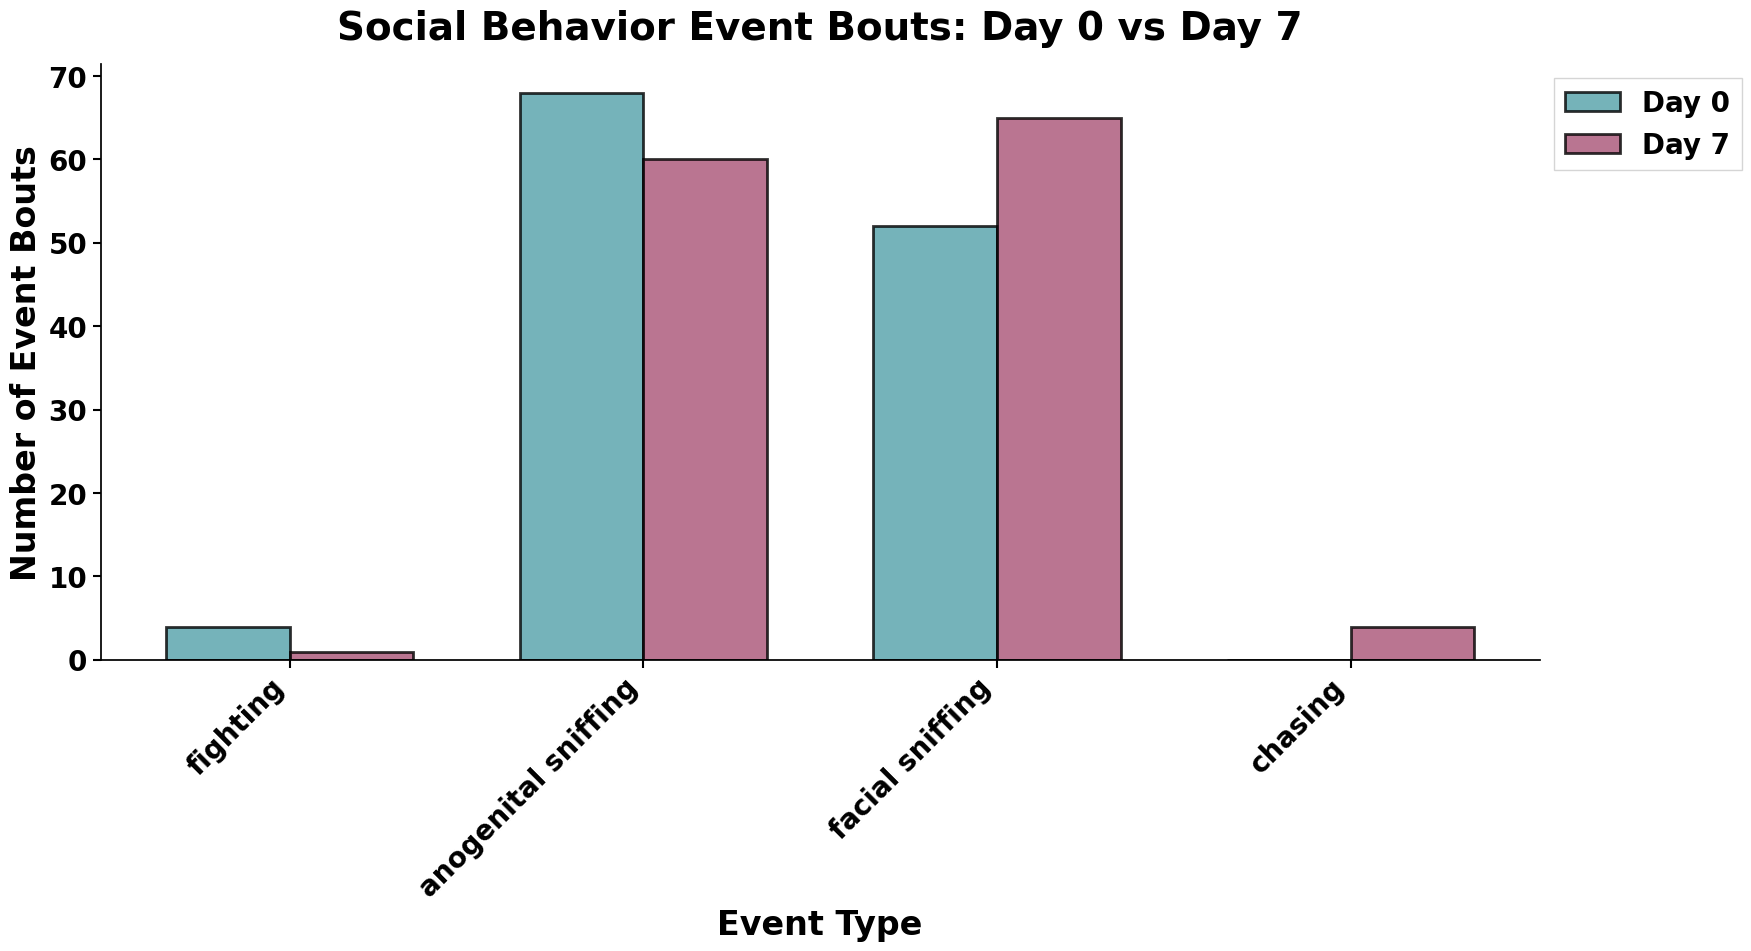

C:\Users\thoma\AppData\Local\Temp\ipykernel_42204\2144663000.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(tick)}" for tick in ax.get_yticks()], fontsize=20, weight='bold')



BEHAVIORAL EVENT BOUTS - OBJECT SNIFFING

Object behavior:
  sniffing object: d0=139, d7=89, total=228


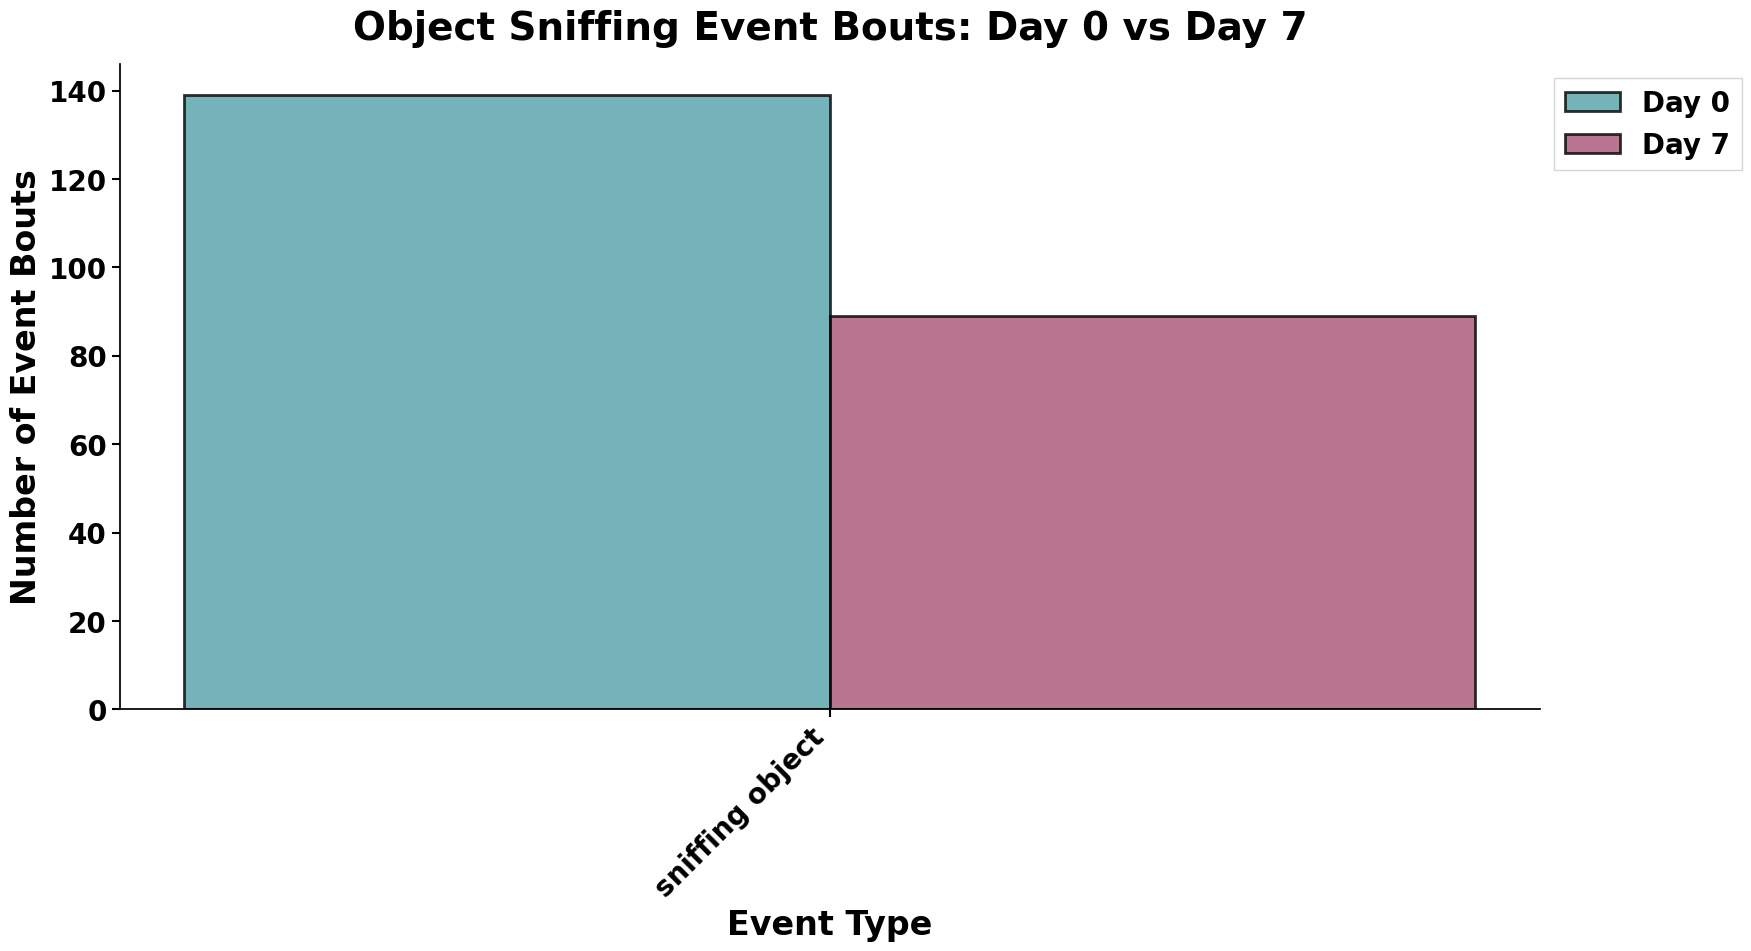


Total event bouts across all types:
  d0: 263
  d7: 219
  Total: 482


In [1428]:
# Bar plot: Number of behavioral event bouts per event type, separated by d0 and d7
# Count event bouts (not unit tests) from the recordings

# Events to exclude
exclude_events = ['mice back in', 'mice taken out']

# Count event bouts for each event type and day
event_bout_counts_d0 = {}
event_bout_counts_d7 = {}

# Extract from the recordings directly
for rec in sc.recordings:
    day = extract_day_from_recording(rec.name)
    for event_name, event_windows in rec.event_dict.items():
        # Skip excluded events
        if event_name in exclude_events:
            continue
            
        n_bouts = len(event_windows)
        if day == 'd0':
            if event_name not in event_bout_counts_d0:
                event_bout_counts_d0[event_name] = 0
            event_bout_counts_d0[event_name] += n_bouts
        elif day == 'd7':
            if event_name not in event_bout_counts_d7:
                event_bout_counts_d7[event_name] = 0
            event_bout_counts_d7[event_name] += n_bouts

# Get all unique events from both days (excluding filtered events)
all_events_bouts = sorted(set(event_bout_counts_d0.keys()) | set(event_bout_counts_d7.keys()))

# Define custom order for events
event_order = ['fighting', 'anogenital sniffing', 'sniffing object', 'facial sniffing', 'chasing']

# Sort events according to custom order (only include events that exist)
all_events_bouts = [e for e in event_order if e in all_events_bouts]

# Separate social behaviors from object sniffing
social_events_bouts = [e for e in all_events_bouts if e != 'sniffing object']
object_events_bouts = [e for e in all_events_bouts if e == 'sniffing object']

# Function to create event bout plot for a set of events
def create_bout_plot(events_to_plot, title_suffix):
    if not events_to_plot:
        return
    
    # Prepare data for plotting
    d0_bout_counts = [event_bout_counts_d0.get(event, 0) for event in events_to_plot]
    d7_bout_counts = [event_bout_counts_d7.get(event, 0) for event in events_to_plot]
    
    # Create side-by-side bar plot with new styling
    fig, ax = plt.subplots(figsize=(18, 10))
    
    # Transparent background
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    x = np.arange(len(events_to_plot))
    
    # Adjust bar width based on number of events (narrower for single event)
    if len(events_to_plot) == 1:
        width = 0.12  # Much narrower for single event (about 1/3 of default)
    else:
        width = 0.35  # Default width for multiple events
    
    # Create bars with new colors
    bars1 = ax.bar(x - width/2, d0_bout_counts, width, label='Day 0', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY0)
    bars2 = ax.bar(x + width/2, d7_bout_counts, width, label='Day 7', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY7)
    
    # Font sizes with bold weight
    ax.set_ylabel('Number of Event Bouts', fontsize=24, weight='bold')
    ax.set_xlabel('Event Type', fontsize=24, weight='bold')
    ax.set_title(f'{title_suffix}: Day 0 vs Day 7', fontsize=28, weight='bold', pad=18)
    
    # Clean up x-axis labels (remove parentheses and make them more readable)
    clean_event_labels = []
    for event in events_to_plot:
        # Remove any parentheses in the event names
        clean_label = event.replace('(', '').replace(')', '')
        clean_event_labels.append(clean_label)
    
    ax.set_xticks(x)
    ax.set_xticklabels(clean_event_labels, rotation=45, ha='right', fontsize=20, weight='bold')
    ax.tick_params(axis='y', labelsize=20, width=1.5, length=6)
    ax.tick_params(axis='x', width=1.5, length=6)

    ax.set_yticklabels([f"{int(tick)}" for tick in ax.get_yticks()], fontsize=20, weight='bold')
    
    # Legend positioned outside plot area with bold text
    legend = ax.legend(fontsize=20, frameon=True, fancybox=False,
                       loc='upper left', bbox_to_anchor=(1.0, 1.0))
    for text in legend.get_texts():
        text.set_weight('bold')
    
    # Apply seaborn despine
    sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()

# Create plot for social behavior bouts
print("="*100)
print("BEHAVIORAL EVENT BOUTS - SOCIAL BEHAVIORS")
print("="*100)
print(f"\nSocial behaviors:")
for event in social_events_bouts:
    d0_bouts = event_bout_counts_d0.get(event, 0)
    d7_bouts = event_bout_counts_d7.get(event, 0)
    total_bouts = d0_bouts + d7_bouts
    print(f"  {event}: d0={d0_bouts}, d7={d7_bouts}, total={total_bouts}")

create_bout_plot(social_events_bouts, 'Social Behavior Event Bouts')

# Create plot for object sniffing bouts
print("\n" + "="*100)
print("BEHAVIORAL EVENT BOUTS - OBJECT SNIFFING")
print("="*100)
print(f"\nObject behavior:")
for event in object_events_bouts:
    d0_bouts = event_bout_counts_d0.get(event, 0)
    d7_bouts = event_bout_counts_d7.get(event, 0)
    total_bouts = d0_bouts + d7_bouts
    print(f"  {event}: d0={d0_bouts}, d7={d7_bouts}, total={total_bouts}")

create_bout_plot(object_events_bouts, 'Object Sniffing Event Bouts')

# Print totals
total_bouts_d0 = sum(event_bout_counts_d0.values())
total_bouts_d7 = sum(event_bout_counts_d7.values())
print("\n" + "="*100)
print(f"Total event bouts across all types:")
print(f"  d0: {total_bouts_d0}")
print(f"  d7: {total_bouts_d7}")
print(f"  Total: {total_bouts_d0 + total_bouts_d7}")
print("="*100)

C:\Users\thoma\AppData\Local\Temp\ipykernel_42204\3850820326.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(tick)}" for tick in ax.get_yticks()], fontsize=18, weight='bold')


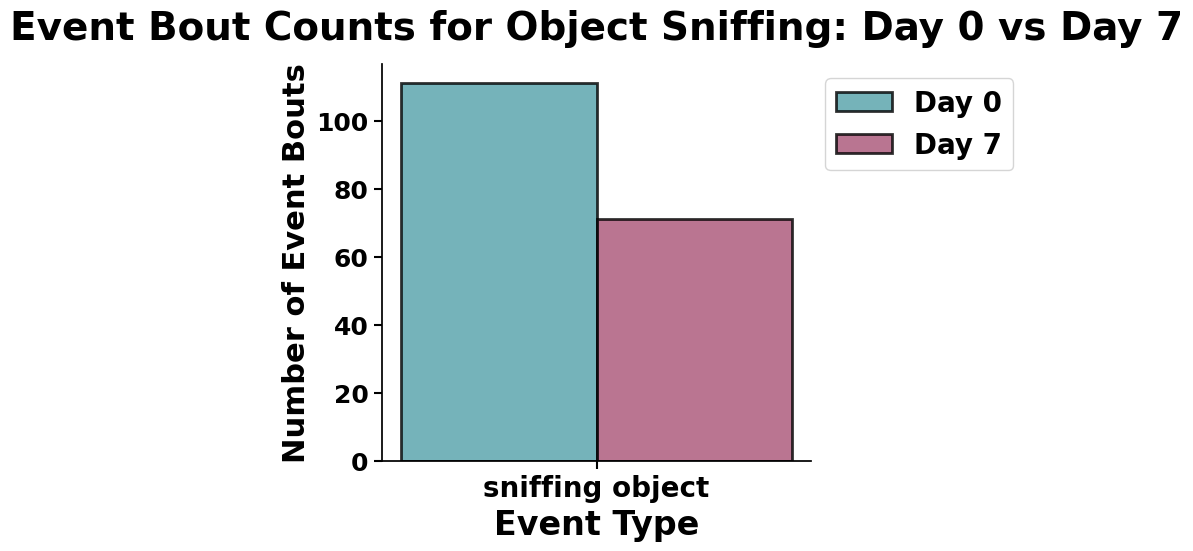

In [1429]:
def object_bout_plot(events_to_plot, title_suffix):
    """
    Plot event bout counts for object events, comparing Day 0 vs Day 7.
    Similar styling to object_plot but for bout counts instead of significant units.
    """
    if not events_to_plot:
        return
    
    # Prepare bout count data
    d0_bout_counts = [event_bout_counts_d0.get(event, 0) for event in events_to_plot]
    d7_bout_counts = [event_bout_counts_d7.get(event, 0) for event in events_to_plot]
    
    # Figure size tuned for 1–2 bars
    fig_width = 6 + 2 * len(events_to_plot)
    fig_height = 6
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Transparent background
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    x = np.arange(len(events_to_plot))
    width = 0.25 if len(events_to_plot) <= 2 else 0.35  # narrower if few bars
    
    # Bars with teal/magenta colors
    bars1 = ax.bar(x - width/2, d0_bout_counts, width, label='Day 0', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY0)
    bars2 = ax.bar(x + width/2, d7_bout_counts, width, label='Day 7', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY7)
    
    # Labels and title with bold fonts
    ax.set_ylabel('Number of Event Bouts', fontsize=22, weight='bold')
    ax.set_xlabel('Event Type', fontsize=24, weight='bold')
    ax.set_title(f'{title_suffix}: Day 0 vs Day 7', fontsize=28, weight='bold', pad=18)
    
    clean_labels = [event.replace('(', '').replace(')', '') for event in events_to_plot]
    ax.set_xticks(x)
    ax.set_xticklabels(clean_labels, fontsize=20, weight='bold')
    ax.tick_params(axis='y', labelsize=20, width=1.5, length=6)
    ax.tick_params(axis='x', width=1.5, length=6)

    ax.set_yticklabels([f"{int(tick)}" for tick in ax.get_yticks()], fontsize=18, weight='bold')

    
    # Legend positioned outside plot area with bold text
    legend = ax.legend(fontsize=20, loc='upper left', bbox_to_anchor=(1.0, 1.0))
    for text in legend.get_texts():
        text.set_weight('bold')

    # Apply seaborn despine
    sns.despine(ax=ax)
    
    
    plt.tight_layout()
    plt.show()

# Create bout count plot for object events
object_bout_plot(object_events, 'Event Bout Counts for Object Sniffing')

### Calculate Average Event Length by Event Type for d0 vs d7

Calculate the mean duration of each behavioral event type for day 0 and day 7 recordings.

In [1430]:
def calculate_event_lengths_by_day(spike_collection, exclude_events=None):
    """
    Calculate average event length for each event type, separated by day (d0 vs d7).
    
    Parameters:
    - spike_collection: SpikeCollection object with recordings
    - exclude_events: List of event names to exclude (default: None)
    
    Returns:
    - event_lengths_df: DataFrame with average event lengths by event type and day
    """
    if exclude_events is None:
        exclude_events = []
    
    # Separate recordings by day
    recordings_d0 = [rec for rec in spike_collection.recordings if extract_day_from_recording(rec.name) == 'd0']
    recordings_d7 = [rec for rec in spike_collection.recordings if extract_day_from_recording(rec.name) == 'd7']
    
    def process_recordings(recordings, day_label):
        """Process a list of recordings and return event length statistics"""
        event_data = []
        
        for rec in recordings:
            for event_name, event_windows in rec.event_dict.items():
                # Skip excluded events
                if event_name in exclude_events:
                    continue
                    
                for start_ms, stop_ms in event_windows:
                    duration_s = (stop_ms - start_ms) / 1000.0  # Convert to seconds
                    event_data.append({
                        'Recording': rec.name,
                        'Day': day_label,
                        'Event': event_name,
                        'Duration_s': duration_s
                    })
        
        return event_data
    
    # Process both d0 and d7
    all_data = []
    all_data.extend(process_recordings(recordings_d0, 'd0'))
    all_data.extend(process_recordings(recordings_d7, 'd7'))
    
    # Convert to DataFrame
    df = pd.DataFrame(all_data)
    
    # Calculate summary statistics by event type and day
    if not df.empty:
        summary = df.groupby(['Day', 'Event'])['Duration_s'].agg([
            ('Mean_Duration_s', 'mean'),
            ('Std_Duration_s', 'std'),
            ('Median_Duration_s', 'median'),
            ('Min_Duration_s', 'min'),
            ('Max_Duration_s', 'max'),
            ('N_Bouts', 'count')
        ]).reset_index()
        
        return df, summary
    else:
        return df, pd.DataFrame()

# Calculate event lengths (excluding mice back in and mice taken out events)
event_lengths_full, event_lengths_summary = calculate_event_lengths_by_day(
    sc, 
    exclude_events=['mice back in', 'mice taken out']
)

print("="*80)
print("AVERAGE EVENT LENGTHS BY EVENT TYPE AND DAY")
print("="*80)
print("(Excluding: 'mice back in' and 'mice taken out' events)")
print(f"\nTotal bouts analyzed: {len(event_lengths_full)}")
print(f"  - d0 bouts: {len(event_lengths_full[event_lengths_full['Day'] == 'd0'])}")
print(f"  - d7 bouts: {len(event_lengths_full[event_lengths_full['Day'] == 'd7'])}")
print(f"\nUnique event types: {event_lengths_full['Event'].nunique()}")

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
event_lengths_summary

AVERAGE EVENT LENGTHS BY EVENT TYPE AND DAY
(Excluding: 'mice back in' and 'mice taken out' events)

Total bouts analyzed: 482
  - d0 bouts: 263
  - d7 bouts: 219

Unique event types: 5

SUMMARY TABLE


,Day,Event,Mean_Duration_s,Std_Duration_s,Median_Duration_s,Min_Duration_s,Max_Duration_s,N_Bouts
0,d0,anogenital sniffing,2.585578,3.693559,1.697700,0.13860,27.50950,68
1,d0,facial sniffing,1.075876,0.910554,0.866150,0.06930,3.67255,52
2,d0,fighting,5.815437,6.240449,3.523550,1.38585,14.82880,4
3,d0,sniffing object,1.741206,2.091164,0.970100,0.06930,11.71060,139
4,d7,anogenital sniffing,2.576808,3.440725,1.628400,0.20785,23.14400,60
5,d7,chasing,0.554375,0.149682,0.519725,0.41580,0.76225,4
6,d7,facial sniffing,1.371185,0.945366,1.039400,0.13855,3.94975,65
7,d7,fighting,0.805600,NaN,0.805600,0.80560,0.80560,1
8,d7,sniffing object,1.161856,0.882655,0.970100,0.13860,4.01905,89


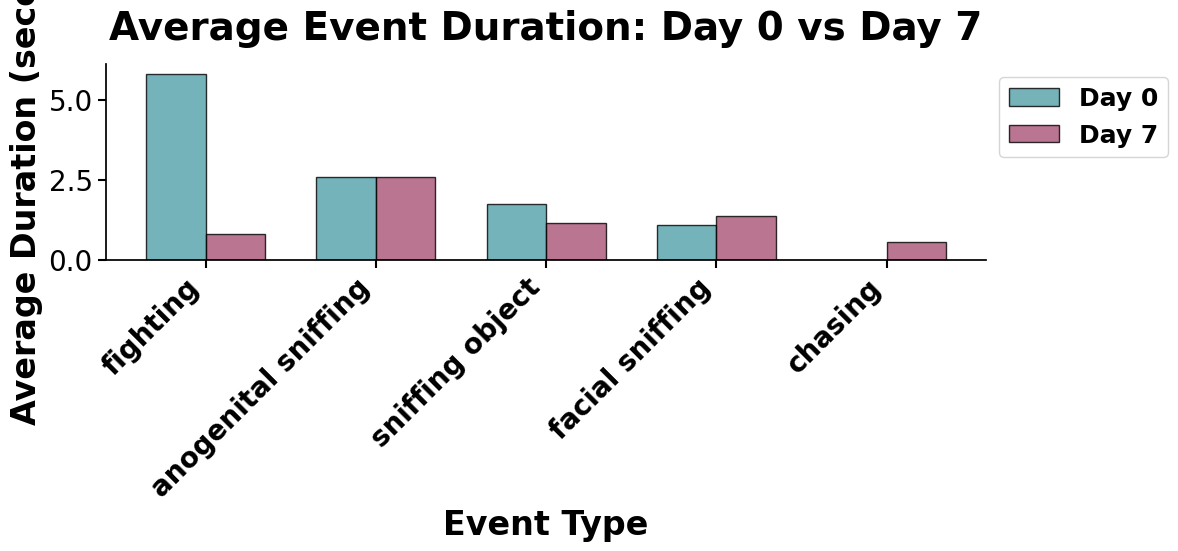


DETAILED EVENT DURATION COMPARISON: Day 0 vs Day 7

Event                           d0 Mean (s)  d7 Mean (s)     Change   N (d0)   N (d7)
--------------------------------------------------------------------------------
fighting                               5.82         0.81     -86.1%        4        1
anogenital sniffing                    2.59         2.58      -0.3%       68       60
sniffing object                        1.74         1.16     -33.3%      139       89
facial sniffing                        1.08         1.37      27.4%       52       65
chasing                                 nan         0.55       0.0%        0        4


In [1431]:
# Create a comparison visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Transparent background
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')

# Side-by-side bar chart comparing d0 vs d7 average durations
pivot_data = event_lengths_summary.pivot(index='Event', columns='Day', values='Mean_Duration_s')

# Apply custom event order
event_order = ['fighting', 'anogenital sniffing', 'sniffing object', 'facial sniffing', 'chasing']
ordered_events = [e for e in event_order if e in pivot_data.index]
pivot_data = pivot_data.reindex(ordered_events)

x = np.arange(len(pivot_data))
width = 0.35

bars1 = ax.bar(x - width/2, pivot_data['d0'], width, label='Day 0', alpha=0.8, 
               edgecolor='black', color=COLOR_DAY0)
bars2 = ax.bar(x + width/2, pivot_data['d7'], width, label='Day 7', alpha=0.8, 
               edgecolor='black', color=COLOR_DAY7)

ax.set_xlabel('Event Type', fontsize=24, weight='bold')
ax.set_ylabel('Average Duration (seconds)', fontsize=24, weight='bold')
ax.set_title('Average Event Duration: Day 0 vs Day 7', fontsize=28, weight='bold', pad=18)
ax.set_xticks(x)
ax.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=20, weight='bold')
ax.tick_params(axis='y', labelsize=20, width=1.5, length=6)
ax.tick_params(axis='x', width=1.5, length=6)
legend = ax.legend(fontsize=18, loc='upper left', bbox_to_anchor=(1.0, 1.0))
for text in legend.get_texts():
    text.set_weight('bold')

# Apply seaborn despine
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n" + "="*80)
print("DETAILED EVENT DURATION COMPARISON: Day 0 vs Day 7")
print("="*80)
print(f"\n{'Event':<30s} {'d0 Mean (s)':>12s} {'d7 Mean (s)':>12s} {'Change':>10s} {'N (d0)':>8s} {'N (d7)':>8s}")
print("-"*80)

for event in pivot_data.index:
    d0_mean = pivot_data.loc[event, 'd0']
    d7_mean = pivot_data.loc[event, 'd7']
    pct_change = ((d7_mean - d0_mean) / d0_mean * 100) if not np.isnan(d0_mean) and d0_mean > 0 else 0
    
    # Get N bouts
    n_d0 = event_lengths_summary[(event_lengths_summary['Event'] == event) & 
                                  (event_lengths_summary['Day'] == 'd0')]['N_Bouts'].values
    n_d7 = event_lengths_summary[(event_lengths_summary['Event'] == event) & 
                                  (event_lengths_summary['Day'] == 'd7')]['N_Bouts'].values
    
    n_d0_val = n_d0[0] if len(n_d0) > 0 else 0
    n_d7_val = n_d7[0] if len(n_d7) > 0 else 0
    
    print(f"{event:<30s} {d0_mean:>12.2f} {d7_mean:>12.2f} {pct_change:>9.1f}% {n_d0_val:>8.0f} {n_d7_val:>8.0f}")

In [1432]:
print(f"Mean Fano: {np.mean(fano_factors):.2f}")
print(f"Median Fano: {np.median(fano_factors):.2f}")
print(f"Range: [{np.min(fano_factors):.2f}, {np.max(fano_factors):.2f}]")
print(f"Fraction > 1.5: {np.mean(np.array(fano_factors) > 1.5)*100:.1f}%")


Mean Fano: 6.92
Median Fano: 5.45
Range: [1.00, 36.89]
Fraction > 1.5: 89.5%


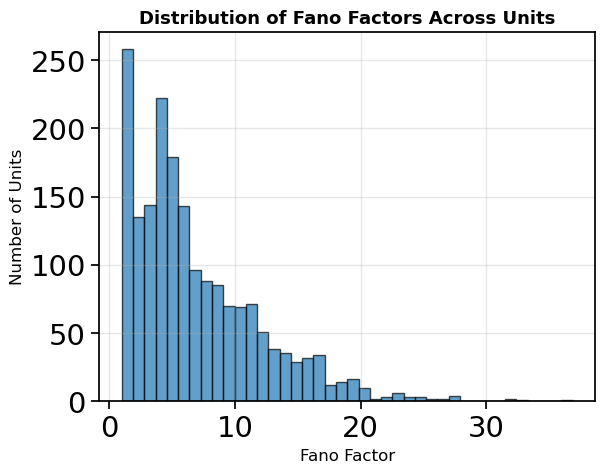

In [1433]:
plt.hist(fano_factors, bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('Fano Factor', fontsize=12)
plt.ylabel('Number of Units', fontsize=12)
plt.title('Distribution of Fano Factors Across Units', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()


## UpSet Plot: Neuron Overlap Across Events and Days

In [1434]:
# Install upsetplot if needed (uncomment to install)
# !pip install upsetplot

from upsetplot import from_contents, UpSet

def create_upset_plot_events_days(df_d0, df_d7, significance_type='both', title="UpSet Plot: Event & Day Overlap"):
    """
    Create an UpSet plot showing overlap between events across days.
    
    Parameters:
    df_d0: DataFrame with d0 results
    df_d7: DataFrame with d7 results
    significance_type: 'both' (increase or decrease), 'increase', 'decrease', or 'all'
    title: Plot title
    """
    # Events to exclude
    exclude_events = ['mice back in', 'mice taken out']
    
    # Get all events
    all_events_d0 = set(df_d0['Event'].unique()) - set(exclude_events)
    all_events_d7 = set(df_d7['Event'].unique()) - set(exclude_events)
    all_events = sorted(all_events_d0 | all_events_d7)
    
    # Build event_sets with unique neuron identifiers (Recording + Unit)
    event_sets = {}
    
    # Process d0 events
    for event in all_events:
        if event in exclude_events:
            continue
            
        # D0 data
        event_df_d0 = df_d0[df_d0['Event'] == event]
        if significance_type == 'both':
            filtered_df_d0 = event_df_d0[event_df_d0['sig'].isin(['increase', 'decrease'])]
        elif significance_type == 'all':
            filtered_df_d0 = event_df_d0
        else:
            filtered_df_d0 = event_df_d0[event_df_d0['sig'] == significance_type]
        
        # Create unique identifiers for d0
        identifiers_d0 = []
        for _, row in filtered_df_d0.iterrows():
            rec = row['Recording']
            unit = row['Unit']
            identifiers_d0.append(f"{rec}_Unit{unit}")
        
        event_sets[f"{event} (Day 0)"] = set(identifiers_d0)
        
        # D7 data
        event_df_d7 = df_d7[df_d7['Event'] == event]
        if significance_type == 'both':
            filtered_df_d7 = event_df_d7[event_df_d7['sig'].isin(['increase', 'decrease'])]
        elif significance_type == 'all':
            filtered_df_d7 = event_df_d7
        else:
            filtered_df_d7 = event_df_d7[event_df_d7['sig'] == significance_type]
        
        # Create unique identifiers for d7
        identifiers_d7 = []
        for _, row in filtered_df_d7.iterrows():
            rec = row['Recording']
            unit = row['Unit']
            identifiers_d7.append(f"{rec}_Unit{unit}")
        
        event_sets[f"{event} (Day 7)"] = set(identifiers_d7)
    
    # Convert dict to upset-compatible format
    data = from_contents(event_sets)
    
    # Create the plot with transparent background
    fig = plt.figure(figsize=(16, 8))
    fig.patch.set_alpha(0.0)
    
    # Plot using sort_by='cardinality' for clearer visualization
    upset = UpSet(data, subset_size='count', show_counts=True, sort_by='cardinality',
                  element_size=32, intersection_plot_elements=6)
    upset.style_subsets(present=list(event_sets.keys()), 
                       facecolor=COLOR_DAY0, 
                       edgecolor='black', 
                       linewidth=1.5)
    
    upset.plot(fig=fig)
    
    # Apply transparent background to all axes
    for ax in fig.get_axes():
        ax.set_facecolor('none')
        # Apply despine to all axes
        sns.despine(ax=ax)
        # Update tick parameters
        ax.tick_params(width=1.5, length=6, labelsize=14)
    
    plt.suptitle(title, fontsize=26, y=1.02)
    
    # Count total unique units
    all_units = set()
    for units in event_sets.values():
        all_units.update(units)
    
    plt.figtext(0.02, 0.02, f"Total unique units: {len(all_units)}", 
                fontsize=18, ha='left')
    
    plt.tight_layout()
    plt.show()
    
    return event_sets, all_units


def count_unique_units_by_category(df_d0, df_d7, events=None, significance_type='both'):
    """
    Count unique units across specified events using Recording + Unit identifiers.
    
    Parameters:
    df_d0, df_d7: DataFrames with unit data
    events: list of event names to include (if None, uses all events except excluded)
    significance_type: 'both', 'increase', 'decrease', or 'all'
    
    Returns:
    int: total number of unique units
    """
    exclude_events = ['mice back in', 'mice taken out']
    
    if events is None:
        # Get all events excluding the specified ones
        all_events_d0 = set(df_d0['Event'].unique()) - set(exclude_events)
        all_events_d7 = set(df_d7['Event'].unique()) - set(exclude_events)
        events = list(all_events_d0 | all_events_d7)
    
    # Combine both dataframes
    df_combined = pd.concat([df_d0, df_d7], ignore_index=True)
    
    # Filter by events
    filtered_df = df_combined[df_combined['Event'].isin(events)]
    
    # Filter by significance type
    if significance_type == 'both':
        filtered_df = filtered_df[filtered_df['sig'].isin(['increase', 'decrease'])]
    elif significance_type == 'all':
        pass  # Include all significance types
    else:
        filtered_df = filtered_df[filtered_df['sig'] == significance_type]
    
    # Construct unique identifiers
    unique_units = set()
    for _, row in filtered_df.iterrows():
        rec = row['Recording']
        unit = row['Unit']
        unique_units.add(f"{rec}_Unit{unit}")
    
    return len(unique_units)

UPSET PLOT: ALL EVENTS ACROSS DAYS


c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].f

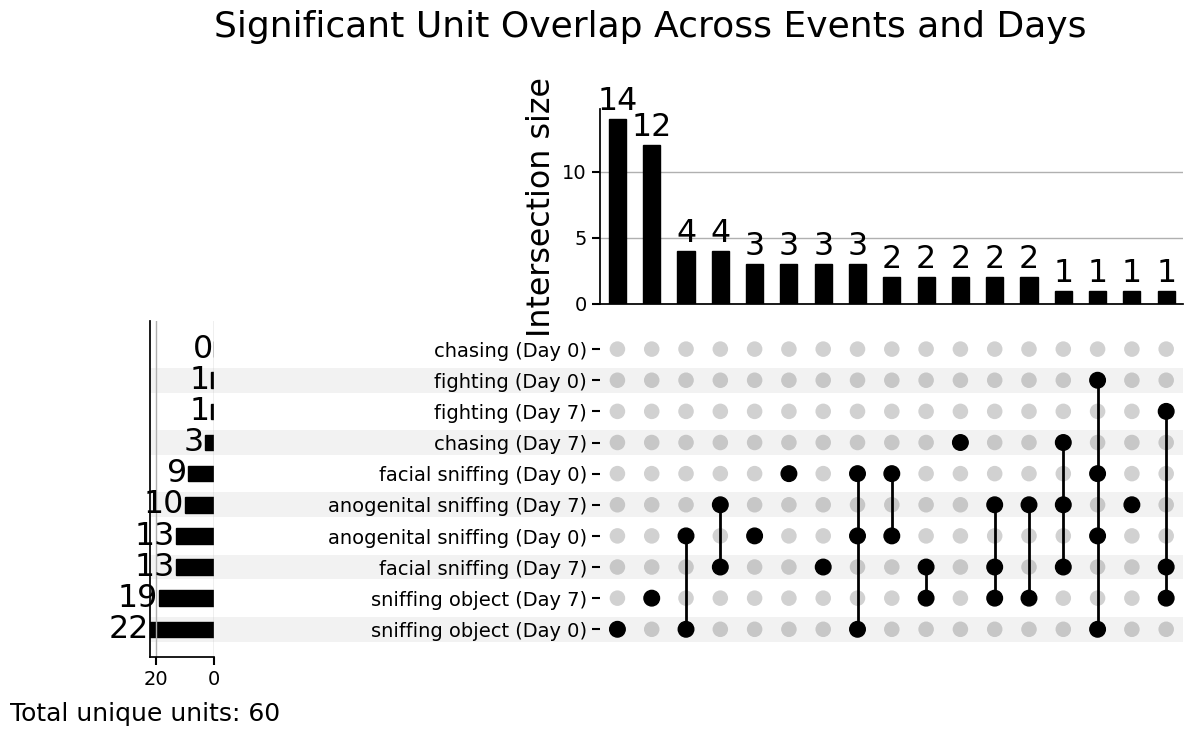


Total unique significant units across all events and days: 60


In [1435]:
# Create UpSet plot for all events (both days combined)
print("="*100)
print("UPSET PLOT: ALL EVENTS ACROSS DAYS")
print("="*100)

event_sets, all_units = create_upset_plot_events_days(
    df_d0, df_d7, 
    significance_type='both',
    title="Significant Unit Overlap Across Events and Days"
)

print(f"\nTotal unique significant units across all events and days: {len(all_units)}")

In [1436]:
# Print summary statistics for each event-day combination
print("\n" + "="*100)
print("SUMMARY: UNIQUE UNITS PER EVENT-DAY COMBINATION")
print("="*100)

for event_name, units in sorted(event_sets.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{event_name:<40s}: {len(units):>4d} unique units")

print("\n" + "="*100)
print("OVERALL STATISTICS")
print("="*100)

# Count social events only
social_event_names = ['anogenital sniffing', 'facial sniffing', 'fighting', 'chasing']
social_units_d0 = count_unique_units_by_category(df_d0, df_d7, events=social_event_names, significance_type='both')
print(f"\nUnique units responding to social behaviors (any day):     {social_units_d0}")

# Count object sniffing
object_units = count_unique_units_by_category(df_d0, df_d7, events=['sniffing object'], significance_type='both')
print(f"Unique units responding to object sniffing (any day):     {object_units}")

# Count all events
all_event_units = count_unique_units_by_category(df_d0, df_d7, events=None, significance_type='both')
print(f"Total unique units responding to any event (any day):     {all_event_units}")

print("="*100)


SUMMARY: UNIQUE UNITS PER EVENT-DAY COMBINATION
sniffing object (Day 0)                 :   22 unique units
sniffing object (Day 7)                 :   19 unique units
anogenital sniffing (Day 0)             :   13 unique units
facial sniffing (Day 7)                 :   13 unique units
anogenital sniffing (Day 7)             :   10 unique units
facial sniffing (Day 0)                 :    9 unique units
chasing (Day 7)                         :    3 unique units
fighting (Day 0)                        :    1 unique units
fighting (Day 7)                        :    1 unique units
chasing (Day 0)                         :    0 unique units

OVERALL STATISTICS

Unique units responding to social behaviors (any day):     34
Unique units responding to object sniffing (any day):     41
Total unique units responding to any event (any day):     60



UPSET PLOT: SOCIAL BEHAVIORS ONLY


c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].f

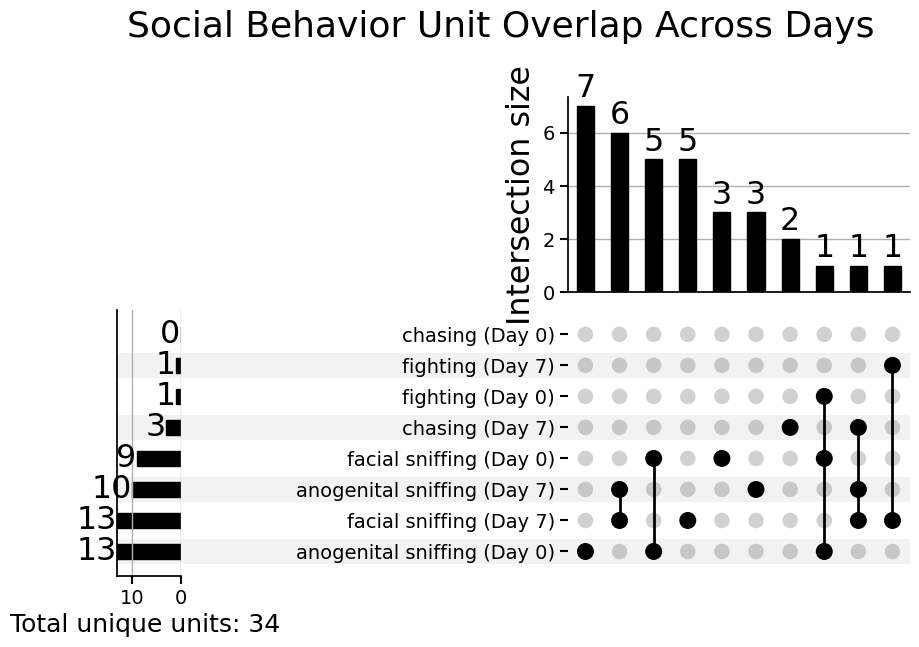


Total unique units responding to social behaviors: 34


In [1437]:
# Create separate UpSet plot for social behaviors only
def create_upset_plot_selected_events(df_d0, df_d7, event_list, significance_type='both', title="UpSet Plot"):
    """
    Create an UpSet plot for specific events.
    """
    exclude_events = ['mice back in', 'mice taken out']
    
    # Build event_sets with unique neuron identifiers (Recording + Unit)
    event_sets = {}
    
    for event in event_list:
        if event in exclude_events:
            continue
            
        # D0 data
        event_df_d0 = df_d0[df_d0['Event'] == event]
        if significance_type == 'both':
            filtered_df_d0 = event_df_d0[event_df_d0['sig'].isin(['increase', 'decrease'])]
        elif significance_type == 'all':
            filtered_df_d0 = event_df_d0
        else:
            filtered_df_d0 = event_df_d0[event_df_d0['sig'] == significance_type]
        
        identifiers_d0 = [f"{row['Recording']}_Unit{row['Unit']}" for _, row in filtered_df_d0.iterrows()]
        event_sets[f"{event} (Day 0)"] = set(identifiers_d0)
        
        # D7 data
        event_df_d7 = df_d7[df_d7['Event'] == event]
        if significance_type == 'both':
            filtered_df_d7 = event_df_d7[event_df_d7['sig'].isin(['increase', 'decrease'])]
        elif significance_type == 'all':
            filtered_df_d7 = event_df_d7
        else:
            filtered_df_d7 = event_df_d7[event_df_d7['sig'] == significance_type]
        
        identifiers_d7 = [f"{row['Recording']}_Unit{row['Unit']}" for _, row in filtered_df_d7.iterrows()]
        event_sets[f"{event} (Day 7)"] = set(identifiers_d7)
    
    # Convert dict to upset-compatible format
    data = from_contents(event_sets)
    
    # Create the plot with transparent background
    fig = plt.figure(figsize=(14, 7))
    fig.patch.set_alpha(0.0)
    
    # Plot
    upset = UpSet(data, subset_size='count', show_counts=True, sort_by='cardinality',
                  element_size=32, intersection_plot_elements=6)
    upset.style_subsets(present=list(event_sets.keys()), 
                       facecolor=COLOR_DAY0, 
                       edgecolor='black', 
                       linewidth=1.5)
    
    upset.plot(fig=fig)
    
    # Apply transparent background to all axes
    for ax in fig.get_axes():
        ax.set_facecolor('none')
        sns.despine(ax=ax)
        ax.tick_params(width=1.5, length=6, labelsize=14)
    
    plt.suptitle(title, fontsize=26, y=1.02)
    
    # Count total unique units
    all_units = set()
    for units in event_sets.values():
        all_units.update(units)
    
    plt.figtext(0.02, 0.02, f"Total unique units: {len(all_units)}", 
                fontsize=18, ha='left')
    
    plt.tight_layout()
    plt.show()
    
    return event_sets, all_units


# Create UpSet plot for social behaviors only
print("\n" + "="*100)
print("UPSET PLOT: SOCIAL BEHAVIORS ONLY")
print("="*100)

social_events = ['anogenital sniffing', 'facial sniffing', 'fighting', 'chasing']
social_event_sets, social_units = create_upset_plot_selected_events(
    df_d0, df_d7,
    event_list=social_events,
    significance_type='both',
    title="Social Behavior Unit Overlap Across Days"
)

print(f"\nTotal unique units responding to social behaviors: {len(social_units)}")

c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].f


UPSET PLOT 1: DAY 0 - ALL EVENTS (SOCIAL + OBJECT)


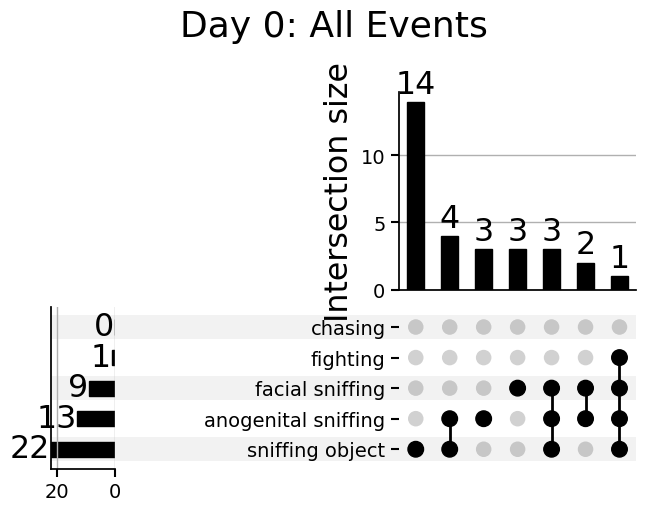


Day 0 total unique units: 30


In [1438]:
# UpSet Plot 1: Day 0 - All Events (Social + Object)
print("\n" + "="*100)
print("UPSET PLOT 1: DAY 0 - ALL EVENTS (SOCIAL + OBJECT)")
print("="*100)

def create_upset_single_day(df, day_label, event_list, significance_type='both', title="UpSet Plot"):
    """
    Create an UpSet plot for a single day with specified events.
    """
    exclude_events = ['mice back in', 'mice taken out']
    
    # Build event_sets with unique neuron identifiers (Recording + Unit)
    event_sets = {}
    
    for event in event_list:
        if event in exclude_events:
            continue
            
        event_df = df[df['Event'] == event]
        if significance_type == 'both':
            filtered_df = event_df[event_df['sig'].isin(['increase', 'decrease'])]
        elif significance_type == 'all':
            filtered_df = event_df
        else:
            filtered_df = event_df[event_df['sig'] == significance_type]
        
        identifiers = [f"{row['Recording']}_Unit{row['Unit']}" for _, row in filtered_df.iterrows()]
        event_sets[f"{event}"] = set(identifiers)
    
    # Convert dict to upset-compatible format
    data = from_contents(event_sets)
    
    # Create the plot with transparent background
    fig = plt.figure(figsize=(14, 7))
    fig.patch.set_alpha(0.0)
    
    # Plot
    upset = UpSet(data, subset_size='count', show_counts=True, sort_by='cardinality',
                  element_size=32, intersection_plot_elements=6)
    upset.style_subsets(present=list(event_sets.keys()), 
                       facecolor=COLOR_DAY0 if 'Day 0' in title else COLOR_DAY7, 
                       edgecolor='black', 
                       linewidth=1.5)
    
    upset.plot(fig=fig)
    
    # Apply transparent background to all axes
    for ax in fig.get_axes():
        ax.set_facecolor('none')
        sns.despine(ax=ax)
        ax.tick_params(width=1.5, length=6, labelsize=14)
    
    # Increased padding for title to move it away from plot
    plt.suptitle(title, fontsize=26, y=1.05)
    
    # Count total unique units
    all_units = set()
    for units in event_sets.values():
        all_units.update(units)
    
    plt.tight_layout()
    plt.show()
    
    return event_sets, all_units

# All events for Day 0
all_events_list = ['anogenital sniffing', 'facial sniffing', 'fighting', 'chasing', 'sniffing object']
d0_all_event_sets, d0_all_units = create_upset_single_day(
    df_d0, 'Day 0',
    event_list=all_events_list,
    significance_type='both',
    title="Day 0: All Events"
)

print(f"\nDay 0 total unique units: {len(d0_all_units)}")


UPSET PLOT 2: DAY 7 - ALL EVENTS (SOCIAL + OBJECT)


c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].f

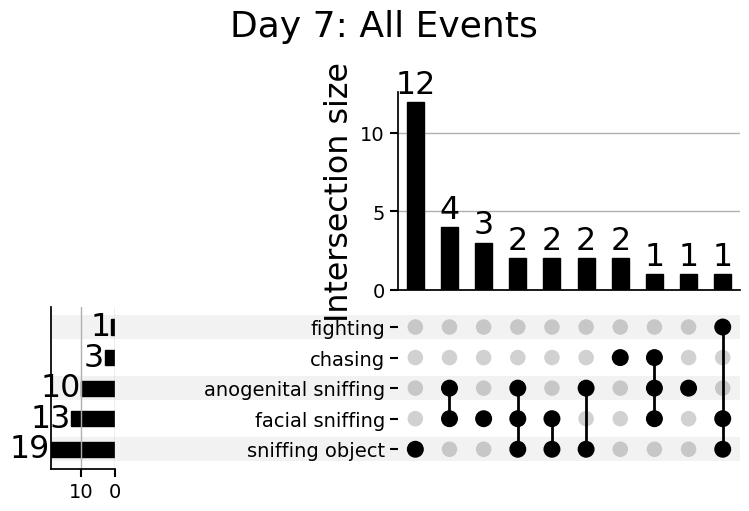


Day 7 total unique units: 30


In [1439]:
# UpSet Plot 2: Day 7 - All Events (Social + Object)
print("\n" + "="*100)
print("UPSET PLOT 2: DAY 7 - ALL EVENTS (SOCIAL + OBJECT)")
print("="*100)

d7_all_event_sets, d7_all_units = create_upset_single_day(
    df_d7, 'Day 7',
    event_list=all_events_list,
    significance_type='both',
    title="Day 7: All Events"
)

print(f"\nDay 7 total unique units: {len(d7_all_units)}")


UPSET PLOT 3: DAY 0 - SOCIAL EVENTS ONLY


c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].f

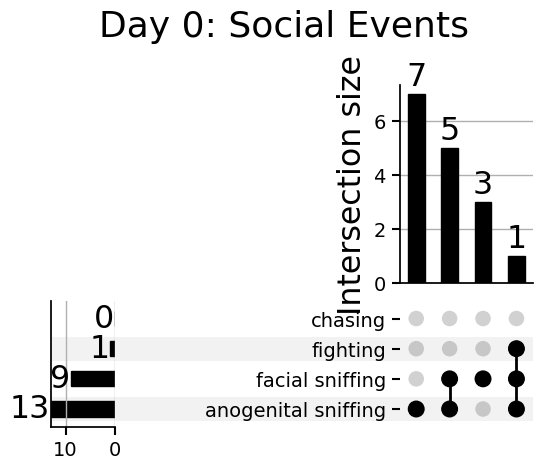


Day 0 social-responsive units: 16


In [1440]:
# UpSet Plot 3: Day 0 - Social Events Only
print("\n" + "="*100)
print("UPSET PLOT 3: DAY 0 - SOCIAL EVENTS ONLY")
print("="*100)

social_events_list = ['anogenital sniffing', 'facial sniffing', 'fighting', 'chasing']
d0_social_event_sets, d0_social_units = create_upset_single_day(
    df_d0, 'Day 0',
    event_list=social_events_list,
    significance_type='both',
    title="Day 0: Social Events"
)

print(f"\nDay 0 social-responsive units: {len(d0_social_units)}")


UPSET PLOT 4: DAY 7 - SOCIAL EVENTS ONLY


c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].f

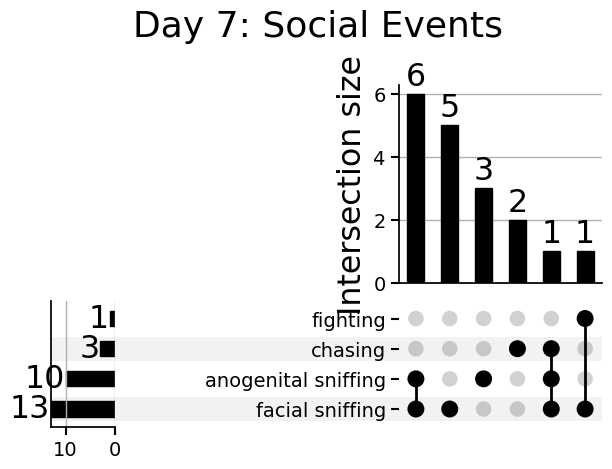


Day 7 social-responsive units: 18


In [1441]:
# UpSet Plot 4: Day 7 - Social Events Only
print("\n" + "="*100)
print("UPSET PLOT 4: DAY 7 - SOCIAL EVENTS ONLY")
print("="*100)

d7_social_event_sets, d7_social_units = create_upset_single_day(
    df_d7, 'Day 7',
    event_list=social_events_list,
    significance_type='both',
    title="Day 7: Social Events"
)

print(f"\nDay 7 social-responsive units: {len(d7_social_units)}")